## This file includes the full implementation, if you wish to run the chatbot, please run the `demo_chatbot.ipynb` file

# Load dataset (Run Once)

When you run this, Colab will pop up a prompt asking you to sign into your Google account and grant permission. Click through and it'll mount. You'll see a little Drive icon appear in the Files panel on the left.

In [ ]:
# @title
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# @title
import os

# This lists everything in your Drive root — find your file/folder from here
for item in os.listdir('/content/drive/MyDrive/NLP'):
    print(item)

pa_restaurants.json
pa_restaurant_reviews.json


In [ ]:
# @title
BASE = '/content/drive/MyDrive/NLP/'  # adjust to your subfolder if needed

# Load JSON files (Yelp format is one JSON object per line)
def load_yelp_json(filepath):
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

print("Loading business data...")
business_df = load_yelp_json(BASE + 'pa_restaurants.json')

print("Loading review data...")
review_df = load_yelp_json(BASE + 'pa_restaurant_reviews.json')

print(f"Total businesses loaded: {len(business_df):,}")
print(f"Total reviews loaded:    {len(review_df):,}")

Loading business data...
Loading review data...
Total businesses loaded: 12,641
Total reviews loaded:    1,100,250


In [ ]:
# @title
# Filter to Philadelphia restaurants only
philly_restaurants = business_df[
    (business_df['city'].str.lower() == 'philadelphia') &
    (business_df['categories'].str.contains('Restaurants', na=False))
].copy()

# Filter reviews to only those matching Philadelphia restaurants
philly_biz_ids = set(philly_restaurants['business_id'])
philly_reviews = review_df[
    review_df['business_id'].isin(philly_biz_ids)
].copy()

print(f"\nPhiladelphia restaurants: {len(philly_restaurants):,}")
print(f"Philadelphia reviews:     {len(philly_reviews):,}")
print(f"Avg reviews per restaurant: {len(philly_reviews)/len(philly_restaurants):.1f}")


Philadelphia restaurants: 5,854
Philadelphia reviews:     687,499
Avg reviews per restaurant: 117.4


In [ ]:
# @title
philly_restaurants.to_csv(BASE + 'philly_restaurants.csv', index=False)
philly_reviews.to_csv(BASE + 'philly_reviews.csv', index=False)

print("Done! Teammates can now load the CSVs directly.")

Done! Teammates can now load the CSVs directly.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/NLP/'
pa_restaurants = pd.read_csv(BASE + 'philly_restaurants.csv')
pa_reviews     = pd.read_csv(BASE + 'philly_reviews.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Exploratory Data Analysis

=== RESTAURANTS ===
Shape: (5854, 14)

Columns:
['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours']

=== REVIEWS ===
Shape: (687499, 9)

Columns:
['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date']
=== RESTAURANT NULL COUNTS ===
business_id       0
name              0
address           0
city              0
state             0
postal_code       0
latitude          0
longitude         0
stars             0
review_count      0
is_open           0
attributes       53
categories        0
hours           998
dtype: int64

=== REVIEW NULL COUNTS ===
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64


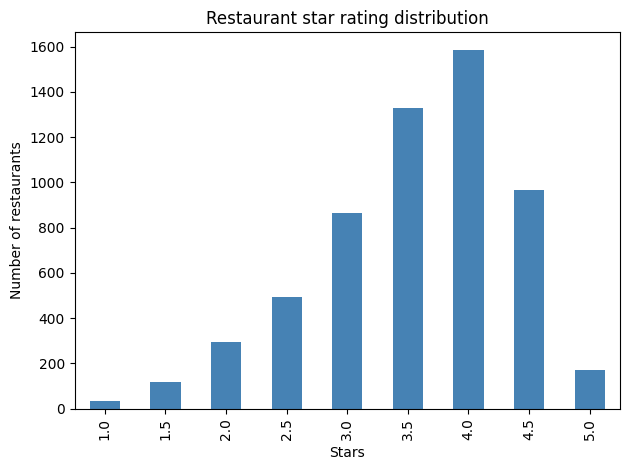

In [ ]:
print("=== RESTAURANTS ===")
print(f"Shape: {philly_restaurants.shape}")
print(f"\nColumns:\n{list(philly_restaurants.columns)}")

print("\n=== REVIEWS ===")
print(f"Shape: {philly_reviews.shape}")
print(f"\nColumns:\n{list(philly_reviews.columns)}")

print("=== RESTAURANT NULL COUNTS ===")
print(philly_restaurants.isnull().sum())

print("\n=== REVIEW NULL COUNTS ===")
print(philly_reviews.isnull().sum())

philly_restaurants['stars'].value_counts().sort_index().plot(
    kind='bar', title='Restaurant star rating distribution', color='steelblue'
)
plt.xlabel('Stars')
plt.ylabel('Number of restaurants')
plt.tight_layout()
plt.show()

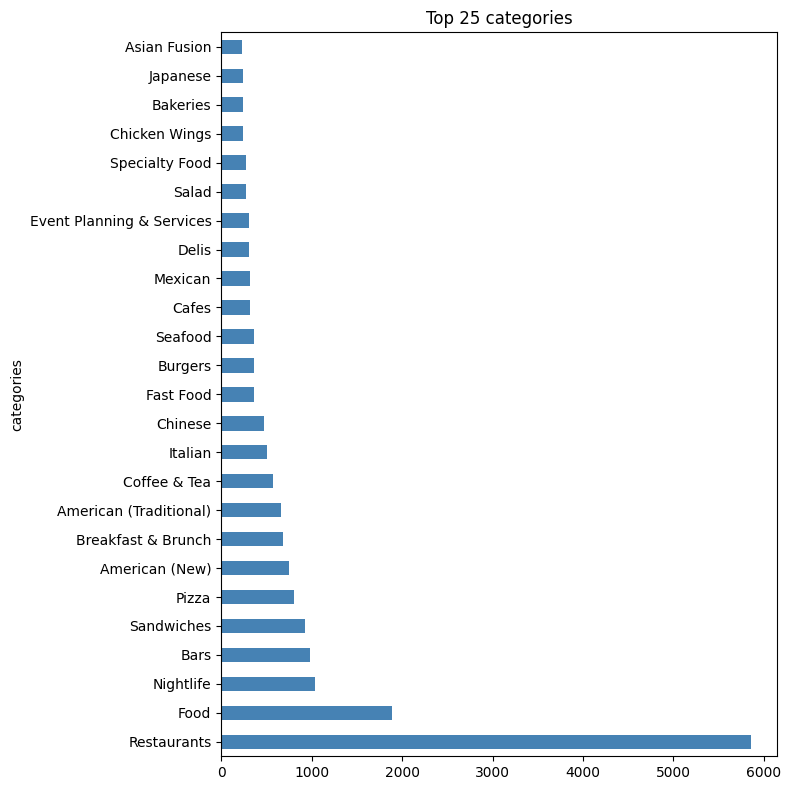

In [ ]:
cuisine_counts = (
    philly_restaurants['categories']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(25)
)

cuisine_counts.plot(kind='barh', figsize=(8, 8), title='Top 25 categories', color='steelblue')
plt.tight_layout()
plt.show()

In [ ]:
price_counts = philly_restaurants['attributes'].apply(
    lambda x: x.get('RestaurantsPriceRange2') if isinstance(x, dict) else None
).value_counts(dropna=False)

print("Price range distribution:")
print(price_counts)
print(f"\nMissing price info: {price_counts.get(None, 0)} restaurants ({price_counts.get(None, 0)/len(philly_restaurants)*100:.1f}%)")

Price range distribution:
attributes
2       2487
1       2165
None     912
3        251
4         38
None       1
Name: count, dtype: int64

Missing price info: 912 restaurants (15.6%)


In [ ]:
key_attrs = [
    'RestaurantsPriceRange2', 'OutdoorSeating', 'GoodForGroups',
    'Ambience', 'WiFi', 'RestaurantsGoodForGroups', 'NoiseLevel',
    'RestaurantsTakeOut', 'RestaurantsDelivery'
]

print(f"{'Attribute':<35} {'Count':>6}  {'Coverage':>8}")
print("-" * 55)
for attr in key_attrs:
    count = philly_restaurants['attributes'].apply(
        lambda x: attr in x if isinstance(x, dict) else False
    ).sum()
    pct = count / len(philly_restaurants) * 100
    print(f"{attr:<35} {count:>6}  {pct:>7.1f}%")

Attribute                            Count  Coverage
-------------------------------------------------------
RestaurantsPriceRange2                4942     84.4%
OutdoorSeating                        4871     83.2%
GoodForGroups                            0      0.0%
Ambience                              4512     77.1%
WiFi                                  4189     71.6%
RestaurantsGoodForGroups              4621     78.9%
NoiseLevel                            3848     65.7%
RestaurantsTakeOut                    5494     93.9%
RestaurantsDelivery                   5393     92.1%


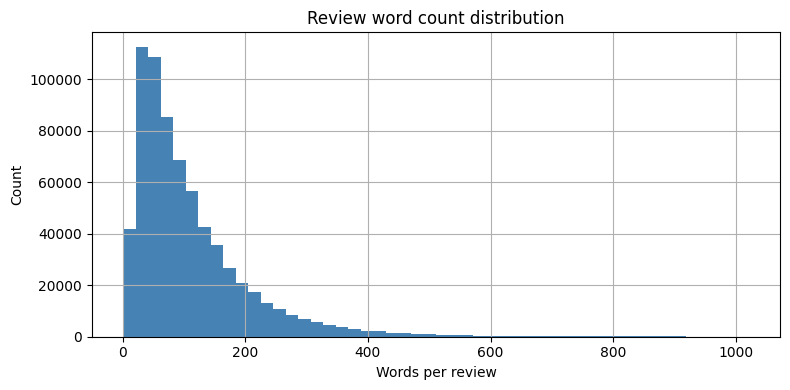

Median review length: 81 words
Mean review length:   110 words


In [ ]:
philly_reviews['review_length'] = philly_reviews['text'].str.split().str.len()

philly_reviews['review_length'].hist(bins=50, color='steelblue', figsize=(8,4))
plt.title('Review word count distribution')
plt.xlabel('Words per review')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Median review length: {philly_reviews['review_length'].median():.0f} words")
print(f"Mean review length:   {philly_reviews['review_length'].mean():.0f} words")

# Building a Knowledge Graph


### Extract Cuisine

In [ ]:
DIETARY_KEYWORDS = ['vegetarian', 'vegan', 'gluten-free', 'halal', 'kosher']

def extract_cuisines(categories_str):
    EXCLUDE = {'restaurants', 'food', 'nightlife', 'bars', 'services',
               'shopping', 'fast food', 'event planning & services'}
    if pd.isna(categories_str):
        return []
    cats = [c.strip().lower() for c in categories_str.split(',')]
    return [c for c in cats if c not in EXCLUDE]

def extract_dietary(categories_str):
    if pd.isna(categories_str):
        return []
    cats = categories_str.lower()
    return [d for d in DIETARY_KEYWORDS if d in cats]

philly_restaurants['cuisines']      = philly_restaurants['categories'].apply(extract_cuisines)
philly_restaurants['dietary_flags'] = philly_restaurants['categories'].apply(extract_dietary)

# Quick sanity check
print(philly_restaurants[['name', 'cuisines', 'dietary_flags']].head(5))

                 name                              cuisines dietary_flags
0  St Honore Pastries  [bubble tea, coffee & tea, bakeries]            []
1            Tuna Bar                [sushi bars, japanese]            []
2                 BAP                              [korean]            []
3             Bar One              [cocktail bars, italian]            []
4    DeSandro on Main                  [pizza, salad, soup]            []


### Normalise Price Range

In [ ]:
def extract_price(attributes):
    if not isinstance(attributes, dict):
        return None
    val = attributes.get('RestaurantsPriceRange2')
    if val is None:
        return None
    try:
        return int(val)
    except:
        return None

philly_restaurants['price_range'] = philly_restaurants['attributes'].apply(extract_price)

print("Price range distribution:")
print(philly_restaurants['price_range'].value_counts(dropna=False))

Price range distribution:
price_range
2.0    2487
1.0    2165
NaN     913
3.0     251
4.0      38
Name: count, dtype: int64


In [ ]:
PRICE_LABELS = {
    1: 'budget',
    2: 'moderate',
    3: 'pricey',
    4: 'upscale'
}

# Also map common user expressions to price values
# Person D will use this in the constraint schema
PRICE_SYNONYMS = {
    'cheap': 1,
    'budget': 1,
    'inexpensive': 1,
    'affordable': 1,
    'moderate': 2,
    'mid-range': 2,
    'midrange': 2,
    'average': 2,
    'pricey': 3,
    'expensive': 3,
    'upscale': 4,
    'fancy': 4,
    'fine dining': 4,
    'splurge': 4
}

philly_restaurants['price_label'] = philly_restaurants['price_range'].map(PRICE_LABELS)

print(philly_restaurants[['name', 'price_range', 'price_label']].head(10))

                                   name  price_range price_label
0                    St Honore Pastries          1.0      budget
1                              Tuna Bar          2.0    moderate
2                                   BAP          1.0      budget
3                               Bar One          2.0    moderate
4                      DeSandro on Main          1.0      budget
6                            Craft Hall          2.0    moderate
11                                 Wawa          1.0      budget
12  Golden Chopstick Chinese Restaurant          1.0      budget
13                              J Sushi          2.0    moderate
15                              Wendy's          1.0      budget


### Extract Key Attributes

In [ ]:
def extract_attr(attributes, key):
    if not isinstance(attributes, dict):
        return None
    val = attributes.get(key)
    if val is None:
        return None
    if isinstance(val, str):
        if val.lower() == 'true':  return True
        if val.lower() == 'false': return False
    return val

philly_restaurants['outdoor_seating'] = philly_restaurants['attributes'].apply(
    lambda x: extract_attr(x, 'OutdoorSeating'))
philly_restaurants['wifi']            = philly_restaurants['attributes'].apply(
    lambda x: extract_attr(x, 'WiFi'))
philly_restaurants['good_for_groups'] = philly_restaurants['attributes'].apply(
    lambda x: extract_attr(x, 'RestaurantsGoodForGroups'))
philly_restaurants['noise_level']     = philly_restaurants['attributes'].apply(
    lambda x: extract_attr(x, 'NoiseLevel'))
philly_restaurants['take_out']        = philly_restaurants['attributes'].apply(
    lambda x: extract_attr(x, 'RestaurantsTakeOut'))
philly_restaurants['delivery']        = philly_restaurants['attributes'].apply(
    lambda x: extract_attr(x, 'RestaurantsDelivery'))

print("Sample attributes:")
print(philly_restaurants[['name', 'outdoor_seating', 'wifi',
                           'good_for_groups', 'noise_level',
                           'take_out', 'delivery']].head(5))

Sample attributes:
                 name outdoor_seating     wifi good_for_groups noise_level  \
0  St Honore Pastries           False  u'free'            None        None   
1            Tuna Bar            True   'free'            True  u'average'   
2                 BAP            None    u'no'           False    u'quiet'   
3             Bar One           False  u'free'            True  u'average'   
4    DeSandro on Main            True     'no'            True   'average'   

  take_out delivery  
0     True    False  
1     True     True  
2     True     None  
3     True     True  
4     True     True  


In [ ]:
def clean_string(val):
    """Strip the u'' unicode prefix and any extra quotes."""
    if val is None:
        return None
    if isinstance(val, str):
        return val.strip("u'\" ")
    return val

# Clean wifi — normalise to: 'free', 'paid', 'no', None
def clean_wifi(val):
    val = clean_string(val)
    if val in ['free', 'paid']:
        return val
    if val in ['no', 'False', 'false']:
        return 'no'
    return None

# Clean noise level — normalise to: 'quiet', 'average', 'loud', 'very_loud', None
def clean_noise(val):
    val = clean_string(val)
    if val in ['quiet', 'average', 'loud', 'very_loud']:
        return val
    return None

philly_restaurants['wifi']        = philly_restaurants['wifi'].apply(clean_wifi)
philly_restaurants['noise_level'] = philly_restaurants['noise_level'].apply(clean_noise)

# Verify
print("WiFi values:")
print(philly_restaurants['wifi'].value_counts(dropna=False))

print("\nNoise level values:")
print(philly_restaurants['noise_level'].value_counts(dropna=False))

WiFi values:
wifi
no      2143
free    2010
None    1667
paid      34
Name: count, dtype: int64

Noise level values:
noise_level
average      2628
None         2009
quiet         759
loud          330
very_loud     128
Name: count, dtype: int64


### Assemble the Knowledge Graph

In [ ]:
knowledge_graph = philly_restaurants[[
    'business_id',
    'name',
    'address',
    'city',
    'latitude',
    'longitude',
    'stars',
    'review_count',
    'cuisines',
    'dietary_flags',
    'price_range',
    'price_label',
    'outdoor_seating',
    'wifi',
    'good_for_groups',
    'noise_level',
    'take_out',
    'delivery'
]].copy()

# Sentiment columns — Person C fills these later
knowledge_graph['sentiment_food']     = None
knowledge_graph['sentiment_service']  = None
knowledge_graph['sentiment_ambience'] = None

print(f"Knowledge graph shape: {knowledge_graph.shape}")
print(f"\nNull counts:")
print(knowledge_graph.isnull().sum())
print(f"\nSample row:")
print(knowledge_graph.iloc[0])

Knowledge graph shape: (5854, 21)

Null counts:
business_id              0
name                     0
address                  0
city                     0
latitude                 0
longitude                0
stars                    0
review_count             0
cuisines                 0
dietary_flags            0
price_range            913
price_label            913
outdoor_seating        983
wifi                  1667
good_for_groups       1233
noise_level           2009
take_out               360
delivery               461
sentiment_food        5854
sentiment_service     5854
sentiment_ambience    5854
dtype: int64

Sample row:
business_id                         MTSW4McQd7CbVtyjqoe9mw
name                                    St Honore Pastries
address                                        935 Race St
city                                          Philadelphia
latitude                                         39.955505
longitude                                       -75.155564
stars

In [ ]:
knowledge_graph.to_csv(BASE + 'knowledge_graph.csv', index=False)
print("Knowledge graph saved to Drive.")

Knowledge graph saved to Drive.


# Data Preprocessing

1. Expand contractions. Converts "wouldn't" → "would not" so that "not" is preserved as a negation signal. Without this, "wouldn't recommend" loses its negative meaning entirely.

2. Lowercase and clean punctuation.Lowercases everything so "AMAZING" and "amazing" are treated the same. Replaces punctuation with spaces (not removes) so "pasta--good" becomes "pasta good" not "pastagood".
3. Tokenise. Splits "the pasta was amazing" into ["the", "pasta", "was", "amazing"]. SentiWordNet works on individual words, not sentences.
4. Remove stopwords, keep negations. Removes meaningless words like "the", "was", "a" that carry no sentiment. But keeps negations like "not", "never", "barely" because they flip sentiment meaning.
5. POS tagging. Labels each word as noun, verb, adjective or adverb. SentiWordNet needs this because "fresh" as an adjective has a different sentiment score than "fresh" as a verb.
6. Lemmatise. Reduces words to their root dictionary form. "overpriced" → "overprice", "amazing" → "amaze". Without this SentiWordNet won't find the word in its dictionary.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import ast

BASE = '/content/drive/MyDrive/NLP/'  # adjust to your folder name

try:
    philly_reviews = pd.read_csv(BASE + 'philly_reviews_preprocessed.csv')
    print("Loaded preprocessed reviews")
except:
    philly_reviews = pd.read_csv(BASE + 'philly_reviews.csv')
    print("Loaded original reviews — preprocessing not yet done")

knowledge_graph = pd.read_csv(BASE + 'knowledge_graph.csv')
philly_restaurants = pd.read_csv(BASE + 'philly_restaurants.csv')

print(f"\nReviews:     {len(philly_reviews):,}")
print(f"KG:          {len(knowledge_graph):,}")
print(f"Restaurants: {len(philly_restaurants):,}")

Mounted at /content/drive
Loaded preprocessed reviews

Reviews:     687,499
KG:          5,854
Restaurants: 5,854


In [ ]:
!pip install contractions

import re
import nltk
import contractions
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Negations must never be removed — they flip sentiment
NEGATIONS = {
    'no', 'not', 'never', 'neither', 'nor',
    'barely', 'hardly', 'scarcely', 'rarely',
    'without', 'nothing', 'nowhere', 'nobody',
    'cannot', 'none'
}
stop_words = stop_words - NEGATIONS

print("Ready.")

Ready.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [ ]:
def clean_text(text):
    """
    Step 1: Expand contractions
        "wouldn't" → "would not"
        "they're"  → "they are"

    Step 2: Lowercase and clean punctuation
        "AMAZING!!" → "amazing"
        "pasta--good" → "pasta  good"
    """
    if not isinstance(text, str):
        return ""
    text = contractions.fix(text)              # step 1
    text = text.lower()                        # step 2a
    text = re.sub(r'http\S+', '', text)        # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)     # replace punctuation with space
    text = re.sub(r'\s+', ' ', text).strip()  # collapse extra spaces
    return text

In [ ]:
def tokenise(text):
    """
    Step 3: Split sentence into individual word tokens.
        "the pasta was amazing"
        → ["the", "pasta", "was", "amazing"]
    """
    return word_tokenize(text)

In [ ]:
def remove_stopwords(tokens):
    """
    Step 4: Remove meaningless words, always keep negations.
        ["the", "pasta", "was", "not", "amazing"]
        → ["pasta", "not", "amazing"]
    """
    return [t for t in tokens if t not in stop_words or t in NEGATIONS]

In [ ]:
def pos_tag_tokens(tokens):
    """
    Step 5: Label each token with its part of speech.
        ["pasta", "not", "amazing"]
        → [("pasta","NN"), ("not","RB"), ("amazing","JJ")]

    POS tags:
        NN = noun       JJ = adjective
        VB = verb       RB = adverb
    """
    return pos_tag(tokens)

In [ ]:
def get_wordnet_pos(treebank_tag):
    """Convert NLTK POS tag to WordNet format for lemmatiser."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatise(tagged_tokens):
    """
    Step 6: Reduce each word to its root dictionary form.
        [("overpriced","JJ"), ("amazing","JJ"), ("pastas","NN")]
        → ["overprice", "amaze", "pasta"]
    """
    return [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged_tokens
    ]

In [ ]:
def preprocess_review(text):
    """
    Runs all 6 steps on a single review.
    Outputs clean tokens and POS tags for
    Person C's sentiment analysis module.
    """
    cleaned    = clean_text(text)
    tokens     = tokenise(cleaned)
    tokens     = remove_stopwords(tokens)
    tagged     = pos_tag_tokens(tokens)
    lemmatised = lemmatise(tagged)

    return {
        'all_tokens': lemmatised,
        'pos_tags':   [tag for _, tag in tagged]
    }

# Test on 3 sample reviews
for i in range(3):
    sample = philly_reviews['text'].iloc[i]
    result = preprocess_review(sample)
    print(f"\n--- Review {i+1} ---")
    print(f"Original:  {sample[:120]}")
    print(f"Tokens:    {result['all_tokens'][:15]}")
    print(f"POS tags:  {result['pos_tags'][:15]}")


--- Review 1 ---
Original:  Wow!  Yummy, different,  delicious.   Our favorite is the lamb curry and korma.  With 10 different kinds of naan!!!  Don
Tokens:    ['wow', 'yummy', 'different', 'delicious', 'favorite', 'lamb', 'curry', 'korma', 'different', 'kind', 'naan', 'not', 'let', 'outside', 'deter']
POS tags:  ['JJ', 'CD', 'JJ', 'JJ', 'NN', 'NN', 'VBP', 'VB', 'JJ', 'NNS', 'MD', 'RB', 'VB', 'IN', 'NN']

--- Review 2 ---
Original:  I am a long term frequent customer of this establishment. I just went in to order take out (3 apps) and was told they're
Tokens:    ['long', 'term', 'frequent', 'customer', 'establishment', 'go', 'order', 'take', 'apps', 'tell', 'busy', 'really', 'place', 'maybe', 'half']
POS tags:  ['JJ', 'NN', 'JJ', 'NN', 'NN', 'VBD', 'NN', 'NN', 'NN', 'VBD', 'JJ', 'RB', 'VBP', 'RB', 'JJ']

--- Review 3 ---
Original:  Good food--loved the gnocchi with marinara
the baked eggplant appetizer was very good too

The service was very slow, bu
Tokens:    ['good', 'food', 'love'

In [ ]:
from tqdm import tqdm
tqdm.pandas()

print("Preprocessing all reviews... (may take 5-10 mins)")

preprocessed = philly_reviews['text'].progress_apply(preprocess_review)

philly_reviews['all_tokens'] = preprocessed.apply(lambda x: x['all_tokens'])
philly_reviews['pos_tags']   = preprocessed.apply(lambda x: x['pos_tags'])

print(f"\nDone. Shape: {philly_reviews.shape}")
print(philly_reviews[['text', 'all_tokens', 'pos_tags']].head(3))

Preprocessing all reviews... (may take 5-10 mins)


100%|██████████| 687499/687499 [59:14<00:00, 193.41it/s]



Done. Shape: (687499, 16)
                                                text  \
0  Wow!  Yummy, different,  delicious.   Our favo...   
1  I am a long term frequent customer of this est...   
2  Good food--loved the gnocchi with marinara\nth...   

                                          all_tokens  \
0  [wow, yummy, different, delicious, favorite, l...   
1  [long, term, frequent, customer, establishment...   
2  [good, food, love, gnocchi, marinara, bake, eg...   

                                            pos_tags  
0  [JJ, CD, JJ, JJ, NN, NN, VBP, VB, JJ, NNS, MD,...  
1  [JJ, NN, JJ, NN, NN, VBD, NN, NN, NN, VBD, JJ,...  
2  [JJ, NN, VBD, JJ, NN, VBD, JJ, NN, JJ, NN, JJ,...  


In [ ]:
philly_reviews.to_csv(BASE + 'philly_reviews_preprocessed.csv', index=False)
print("Saved preprocessed reviews to Drive.")

Saved preprocessed reviews to Drive.


# Sentiment Analysis Module

In [ ]:
!pip install spacy -q
!python -m spacy download en_core_web_sm -q

import spacy
import pandas as pd
import numpy as np
import ast
import nltk
from nltk.corpus import sentiwordnet as swn, wordnet as wn
from functools import lru_cache
from tqdm import tqdm
tqdm.pandas()

nltk.download('sentiwordnet', quiet=True)
nltk.download('wordnet',      quiet=True)

nlp = spacy.load('en_core_web_sm')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 87.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
spacy.prefer_gpu()  # tells spaCy to use GPU if available
nlp = spacy.load('en_core_web_sm')

print("GPU enabled for spaCy" if spacy.prefer_gpu() else "Running on CPU")

GPU enabled for spaCy


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import ast

BASE = '/content/drive/MyDrive/NLP/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
reviews = pd.read_csv(BASE + 'philly_reviews_preprocessed.csv')
kg      = pd.read_csv(BASE + 'knowledge_graph.csv')

# We use the raw text for spaCy — it works on original sentences
# The preprocessed tokens are no longer needed for sentiment
print(f"Reviews: {len(reviews):,}")
print(f"KG rows: {len(kg):,}")
print(f"\nSample review text:")
print(reviews['text'].iloc[0][:200])

Reviews: 687,499
KG rows: 5,854

Sample review text:
Wow!  Yummy, different,  delicious.   Our favorite is the lamb curry and korma.  With 10 different kinds of naan!!!  Don't let the outside deter you (because we almost changed our minds)...go in and t


#  Aspect term dictionaries

In [ ]:
FOOD_TERMS = {
    'food', 'meal', 'dish', 'taste', 'flavor', 'flavour', 'cuisine',
    'menu', 'ingredient', 'portion', 'recipe', 'cooking', 'cook',
    'pasta', 'pizza', 'burger', 'sandwich', 'salad', 'soup', 'steak',
    'chicken', 'fish', 'sushi', 'taco', 'curry', 'naan', 'korma',
    'gnocchi', 'marinara', 'eggplant', 'appetizer', 'dessert',
    'bread', 'cheese', 'sauce', 'seafood', 'lamb', 'beef', 'pork',
    'drink', 'coffee', 'tea', 'beer', 'wine', 'cocktail', 'juice',
    'favorite', 'favourite'
}

SERVICE_TERMS = {
    'service', 'staff', 'waiter', 'waitress', 'server', 'host',
    'hostess', 'manager', 'bartender', 'chef', 'barista',
    'wait', 'attention', 'hospitality', 'order', 'reservation',
    'response', 'attitude', 'professionalism', 'busy', 'rush'
}

AMBIENCE_TERMS = {
    'ambience', 'atmosphere', 'vibe', 'decor', 'interior', 'exterior',
    'place', 'space', 'room', 'location', 'seating', 'seat',
    'table', 'lighting', 'music', 'parking', 'wifi', 'bathroom',
    'restroom', 'outdoor', 'patio', 'view', 'crowd', 'noise', 'line'
}

TERM_TO_ASPECT = {}
for t in FOOD_TERMS:     TERM_TO_ASPECT[t] = 'food'
for t in SERVICE_TERMS:  TERM_TO_ASPECT[t] = 'service'
for t in AMBIENCE_TERMS: TERM_TO_ASPECT[t] = 'ambience'

print(f"Food:     {len(FOOD_TERMS)} terms")
print(f"Service:  {len(SERVICE_TERMS)} terms")
print(f"Ambience: {len(AMBIENCE_TERMS)} terms")

Food:     48 terms
Service:  21 terms
Ambience: 25 terms


In [ ]:
# Words SentiWordNet scores incorrectly or misses entirely
CUSTOM_SENTIMENT = {
    # Positive
    'incredible':    0.90,
    'yummy':         0.90,
    'amazing':       0.85,
    'awesome':       0.85,
    'fantastic':     0.85,
    'delicious':     0.90,
    'wonderful':     0.80,
    'perfect':       0.85,
    'outstanding':   0.90,
    'superb':        0.90,
    'brilliant':     0.80,
    'lovely':        0.75,
    'excellent':     0.85,
    'phenomenal':    0.90,
    'scrumptious':   0.90,
    'tasty':         0.80,
    'favourite':     0.70,
    'favorite':     0.70,
    'mouthwatering': 0.90,
    # Negative
    'overpriced':    -0.80,
    'disgusting':    -0.90,
    'awful':         -0.90,
    'horrible':      -0.90,
    'worst':         -0.90,
    'mediocre':      -0.50,
    'disappointing': -0.70,
    'bland':         -0.60,
    'rude':          -0.80,
    'slow':          -0.50,
    'busy':          -0.40,
    'terrible':      -0.85,
    'dreadful':      -0.85,
    'inedible':      -0.90,
    'stale':         -0.70,
    'soggy':         -0.65,
}

NEGATIONS = {
    'no', 'not', 'never', 'neither', 'nor',
    'barely', 'hardly', 'scarcely', 'rarely',
    'without', 'nothing', 'nowhere', 'nobody',
    'cannot', 'none'
}

def spacy_pos_to_wn(spacy_pos):
    """Convert spaCy POS to WordNet POS."""
    if spacy_pos == 'ADJ': return wn.ADJ
    if spacy_pos == 'ADV': return wn.ADV
    return None

@lru_cache(maxsize=10000)
def sentiment_score(word, spacy_pos):
    """
    Score a word using custom lexicon first,
    fall back to SentiWordNet.
    Only scores adjectives and adverbs —
    these are the only POS that reliably
    carry sentiment in SentiWordNet.
    """
    # Custom lexicon takes priority
    if word in CUSTOM_SENTIMENT:
        return CUSTOM_SENTIMENT[word]

    # SentiWordNet fallback
    wn_pos = spacy_pos_to_wn(spacy_pos)
    if wn_pos is None:
        return 0.0

    synsets = list(swn.senti_synsets(word, wn_pos))
    if not synsets:
        return 0.0

    return sum(
        s.pos_score() - s.neg_score()
        for s in synsets
    ) / len(synsets)

NameError: name 'lru_cache' is not defined

In [ ]:
def score_review_from_doc(doc):
    """
    Score a pre-parsed spaCy doc.
    Called by the GPU batching loop — doc is already parsed.
    """
    aspect_scores = {'food': [], 'service': [], 'ambience': []}

    for token in doc:
        token_lemma = token.lemma_.lower()

        if token_lemma in TERM_TO_ASPECT:
            aspect = TERM_TO_ASPECT[token_lemma]

            noun_negated = any(
                (child.dep_ == 'neg') or
                (child.dep_ == 'det' and
                 child.text.lower() == 'no')
                for child in token.children
            )

            if noun_negated:
                aspect_scores[aspect].append(-1.0)
                continue

            modifiers = [
                child for child in token.children
                if child.dep_ in ('amod', 'advmod', 'acomp')
                and child.pos_ in ('ADJ', 'ADV')
            ]

            if token.dep_ == 'nsubj':
                for sibling in token.head.children:
                    if sibling.dep_ in ('acomp', 'advmod') \
                    and sibling.pos_ in ('ADJ', 'ADV') \
                    and sibling not in modifiers:
                        modifiers.append(sibling)

            # Handle "favorite" as positive signal
            if not modifiers and token_lemma in {'favorite', 'favourite'}:
                aspect_scores['food'].append(0.70)
                continue

            for mod in modifiers:
                s = sentiment_score(mod.lemma_.lower(), mod.pos_)
                if s == 0.0:
                    continue

                mod_idx = mod.i
                local_window = doc[max(0, mod_idx - 3): mod_idx]
                negated = any(
                    t.text.lower() in NEGATIONS
                    for t in local_window
                )
                aspect_scores[aspect].append(-s if negated else s)

        elif token.pos_ in ('ADJ', 'ADV') \
        and token.head.lemma_.lower() in TERM_TO_ASPECT:
            aspect = TERM_TO_ASPECT[token.head.lemma_.lower()]
            s = sentiment_score(token.lemma_.lower(), token.pos_)
            if s == 0.0:
                continue
            negated = any(
                child.dep_ == 'neg'
                for child in token.children
            )
            aspect_scores[aspect].append(-s if negated else s)

    return {
        'food':     float(np.mean(aspect_scores['food']))
                    if aspect_scores['food']     else 0.0,
        'service':  float(np.mean(aspect_scores['service']))
                    if aspect_scores['service']  else 0.0,
        'ambience': float(np.mean(aspect_scores['ambience']))
                    if aspect_scores['ambience'] else 0.0,
    }

def score_review(text):
    """
    Score raw text — used for testing individual reviews.
    For full dataset use score_review_from_doc with nlp.pipe().
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {'food': 0.0, 'service': 0.0, 'ambience': 0.0}
    doc = nlp(text[:1000])
    return score_review_from_doc(doc)

In [ ]:
test_cases = [
    "Food is good, no wifi",
    "The food was absolutely amazing but the service was terrible",
    "The pasta was incredible but service was slow",
    "Wow! Yummy, delicious. Our favorite is the lamb curry and korma",
    "I am a long term frequent customer. They were too busy to take my order. Never going back",
    "Good food, loved the gnocchi. The service was very slow but I would go back",
    "Couldn't believe how rude the waiter was",
    "Romantic spot with great ambience but overpriced food",
    "No outdoor seating but the pasta was worth it",
]

print(f"{'Review':<55} {'Food':>7} {'Service':>9} {'Ambience':>10}")
print("─" * 85)
for review in test_cases:
    scores = score_review(review)
    print(f"{review[:54]:<55} "
          f"{scores['food']:>7.3f} "
          f"{scores['service']:>9.3f} "
          f"{scores['ambience']:>10.3f}")

Review                                                     Food   Service   Ambience
─────────────────────────────────────────────────────────────────────────────────────
Food is good, no wifi                                     0.613     0.000     -1.000
The food was absolutely amazing but the service was te    0.850    -0.850      0.000
The pasta was incredible but service was slow             0.900    -0.500      0.000
Wow! Yummy, delicious. Our favorite is the lamb curry     0.700     0.000      0.000
I am a long term frequent customer. They were too busy    0.000    -0.062      0.000
Good food, loved the gnocchi. The service was very slo    0.613    -0.500      0.000
Couldn't believe how rude the waiter was                  0.000    -0.800      0.000
Romantic spot with great ambience but overpriced food    -0.800     0.000      0.292
No outdoor seating but the pasta was worth it             0.000     0.000     -1.000


In [ ]:
# Check if GPU is available
import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

GPU available: True
GPU name: Tesla T4


In [ ]:
# Ensure GPU is being used
spacy.prefer_gpu()

print("Scoring all reviews with GPU batching...")
print("Expected time: 5-10 mins on GPU\n")

# Collect all review texts
texts = reviews['text'].fillna('').tolist()

# Process in batches using spaCy's pipe
# batch_size controls how many documents are sent to GPU at once
# n_process=1 is correct for GPU (multiple processes don't help on GPU)
BATCH_SIZE = 256

food_scores     = []
service_scores  = []
ambience_scores = []

for doc in tqdm(
    nlp.pipe(texts, batch_size=BATCH_SIZE),
    total=len(texts),
    desc="Scoring reviews"
):
    # score_review currently takes raw text — update it to accept a doc
    scores = score_review_from_doc(doc)
    food_scores.append(scores['food'])
    service_scores.append(scores['service'])
    ambience_scores.append(scores['ambience'])

reviews['score_food']     = food_scores
reviews['score_service']  = service_scores
reviews['score_ambience'] = ambience_scores

print("\n── Score distributions ──")
for col in ['score_food', 'score_service', 'score_ambience']:
    non_zero = reviews[col][reviews[col] != 0]
    print(f"  {col:<20} "
          f"mean={reviews[col].mean():.4f}  "
          f"non-zero mean={non_zero.mean():.4f}  "
          f"non-zero n={len(non_zero):,}")

Scoring all reviews with GPU batching...
Expected time: 5-10 mins on GPU



Scoring reviews: 100%|██████████| 687499/687499 [1:10:43<00:00, 162.01it/s]



── Score distributions ──
  score_food           mean=0.1799  non-zero mean=0.2660  non-zero n=465,084
  score_service        mean=0.0363  non-zero mean=0.0889  non-zero n=280,917
  score_ambience       mean=0.0582  non-zero mean=0.1605  non-zero n=249,358


In [ ]:
review_sentiments = reviews[[
    'review_id', 'business_id', 'stars',
    'score_food', 'score_service', 'score_ambience'
]].copy()

review_sentiments.to_csv(BASE + 'review_sentiments.csv', index=False)
print("Per-review scores saved.")

Per-review scores saved.


In [ ]:
sentiments = pd.read_csv(BASE + 'review_sentiments.csv')
reviews = reviews.merge(
    sentiments[['review_id', 'score_food', 'score_service', 'score_ambience']],
    on='review_id',
    how='left'
)
print(f"Merged. Shape: {reviews.shape}")
print(reviews[['score_food', 'score_service', 'score_ambience']].describe())

Merged. Shape: (687499, 19)
          score_food  score_service  score_ambience
count  687499.000000  687499.000000   687499.000000
mean        0.179946       0.036323        0.058218
std         0.333183       0.302613        0.230290
min        -1.000000      -1.000000       -1.000000
25%         0.000000       0.000000        0.000000
50%         0.050000       0.000000        0.000000
75%         0.385937       0.083333        0.014815
max         1.000000       1.000000        1.000000


### Aggregate sentiment into Knowledge Graph

In [ ]:
if 'useful' not in reviews.columns:
    reviews['useful'] = 1

def weighted_mean(group, col):
    weights = group['useful'].fillna(0).astype(float) + 1.0
    return float(np.average(
        group[col].fillna(0), weights=weights
    ))

print("Aggregating to restaurant level...")
sentiment_agg = (
    reviews.groupby('business_id')
    .apply(lambda g: pd.Series({
        'sentiment_food':     weighted_mean(g, 'score_food'),
        'sentiment_service':  weighted_mean(g, 'score_service'),
        'sentiment_ambience': weighted_mean(g, 'score_ambience'),
        'review_count_used':  len(g),
    }))
    .reset_index()
)

print(f"Aggregated: {len(sentiment_agg):,} restaurants")

# Merge into KG
kg.drop(columns=[
    'sentiment_food', 'sentiment_service', 'sentiment_ambience'
], inplace=True, errors='ignore')

kg = kg.merge(
    sentiment_agg[[
        'business_id', 'sentiment_food',
        'sentiment_service', 'sentiment_ambience'
    ]],
    on='business_id', how='left'
)

kg[['sentiment_food', 'sentiment_service', 'sentiment_ambience']] = \
    kg[['sentiment_food', 'sentiment_service',
        'sentiment_ambience']].fillna(0)

# Normalise to [-1, 1]
def minmax_normalise(series):
    lo, hi = series.min(), series.max()
    if hi == lo:
        return pd.Series(
            np.zeros(len(series)), index=series.index
        )
    return 2 * (series - lo) / (hi - lo) - 1

for col in ['sentiment_food', 'sentiment_service',
            'sentiment_ambience']:
    kg[col + '_norm'] = minmax_normalise(kg[col])

# Validate against star ratings
print("\n── Correlation with Yelp star rating ──")
for col in ['sentiment_food_norm',
            'sentiment_service_norm',
            'sentiment_ambience_norm']:
    r = kg['stars'].corr(kg[col])
    print(f"  stars vs {col:<30} r = {r:.4f}")

# Top 5 by food sentiment
print("\n── Top 5 restaurants by food sentiment ──")
top = (
    kg[kg['review_count'] >= 20]
    .nlargest(5, 'sentiment_food_norm')
    [['name', 'sentiment_food_norm',
      'sentiment_service_norm',
      'sentiment_ambience_norm', 'stars']]
)
print(top.to_string(index=False))

# Bottom 5 by food sentiment
print("\n── Bottom 5 restaurants by food sentiment ──")
bot = (
    kg[kg['review_count'] >= 20]
    .nsmallest(5, 'sentiment_food_norm')
    [['name', 'sentiment_food_norm',
      'sentiment_service_norm',
      'sentiment_ambience_norm', 'stars']]
)
print(bot.to_string(index=False))

# Save
kg.to_csv(
    BASE + 'knowledge_graph_with_sentiment.csv', index=False
)
print("\nKnowledge graph with sentiment saved.")

Aggregating to restaurant level...


/tmp/ipykernel_5356/3215891288.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


Aggregated: 5,854 restaurants

── Correlation with Yelp star rating ──
  stars vs sentiment_food_norm            r = 0.5449
  stars vs sentiment_service_norm         r = 0.3699
  stars vs sentiment_ambience_norm        r = 0.2987

── Top 5 restaurants by food sentiment ──
           name  sentiment_food_norm  sentiment_service_norm  sentiment_ambience_norm  stars
 Federal Donuts             0.747751               -0.447645                 0.088739    4.5
Medusa Pizzeria             0.677953                0.188517                 0.144180    4.0
      moonbowls             0.623244                0.359293                 0.199068    4.5
           Stir             0.615682                0.475143                 0.104469    4.5
   PTG Catering             0.581722                0.308259                 0.158600    4.5

── Bottom 5 restaurants by food sentiment ──
                          name  sentiment_food_norm  sentiment_service_norm  sentiment_ambience_norm  stars
La Tapenade Med

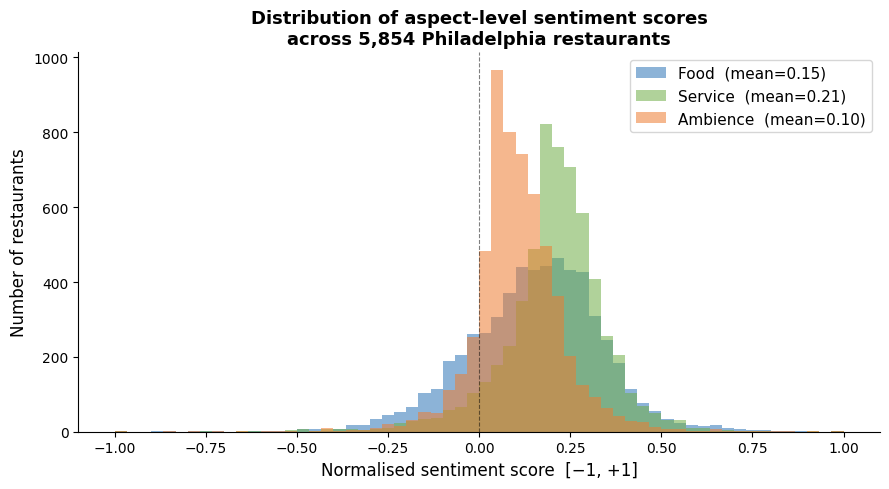

Saved → fig_sentiment_distribution.png


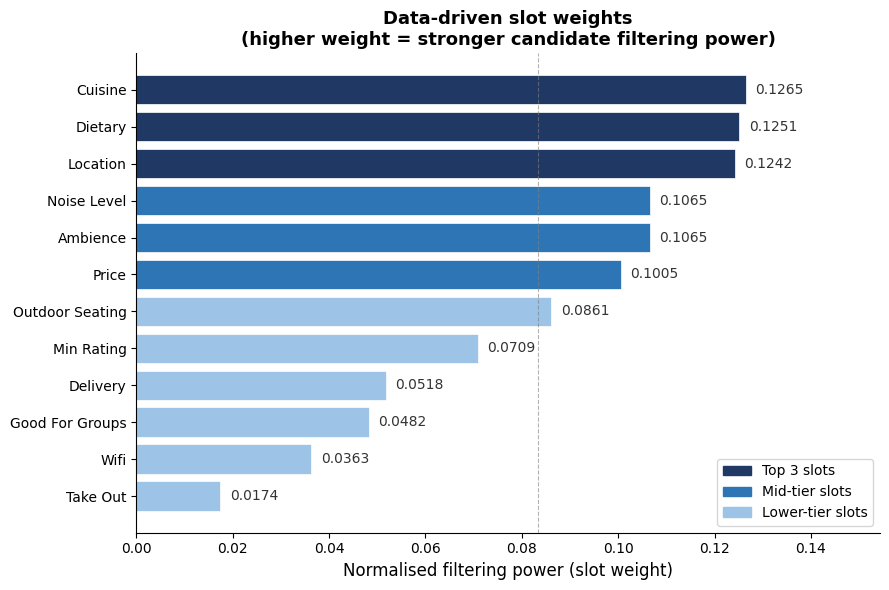

Saved → fig_slot_weights.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json

BASE = '/content/drive/MyDrive/NLP/'

# ── Figure 1: Sentiment Score Distribution ───────────────────────────────────
kg = pd.read_csv(BASE + 'knowledge_graph_neighbourhood_sentiment.csv')

fig, ax = plt.subplots(figsize=(9, 5))

aspects = {
    'Food':     ('sentiment_food_norm',     '#2E75B6'),
    'Service':  ('sentiment_service_norm',  '#70AD47'),
    'Ambience': ('sentiment_ambience_norm', '#ED7D31'),
}

for label, (col, colour) in aspects.items():
    scores = kg[col].dropna()
    ax.hist(scores, bins=60, alpha=0.55, color=colour,
            label=f'{label}  (mean={scores.mean():.2f})', edgecolor='none')

ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Normalised sentiment score  [−1, +1]', fontsize=12)
ax.set_ylabel('Number of restaurants', fontsize=12)
ax.set_title('Distribution of aspect-level sentiment scores\nacross 5,854 Philadelphia restaurants',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(BASE + 'fig_sentiment_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved → fig_sentiment_distribution.png")


# ── Figure 2: Slot Weight Bar Chart ──────────────────────────────────────────
with open(BASE + 'slot_weights.json') as f:
    slot_weights = json.load(f)

# Sort descending by weight
slots_sorted  = sorted(slot_weights.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*slots_sorted)

# Clean up label names for display
display_labels = [l.replace('_', ' ').title() for l in labels]

# Colour: top 3 slots darker to draw attention
colours = ['#1F3864' if i < 3 else '#2E75B6' if i < 6 else '#9DC3E6'
           for i in range(len(labels))]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(display_labels[::-1], values[::-1], color=colours[::-1],
               edgecolor='white', linewidth=0.5)

# Annotate each bar with its weight value
for bar, val in zip(bars, values[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='left', fontsize=10, color='#333333')

ax.set_xlabel('Normalised filtering power (slot weight)', fontsize=12)
ax.set_title('Data-driven slot weights\n(higher weight = stronger candidate filtering power)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, max(values) * 1.22)
ax.axvline(1/len(slot_weights), color='grey', linewidth=0.8,
           linestyle='--', alpha=0.6, label='Uniform baseline')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend for colour tiers
p1 = mpatches.Patch(color='#1F3864', label='Top 3 slots')
p2 = mpatches.Patch(color='#2E75B6', label='Mid-tier slots')
p3 = mpatches.Patch(color='#9DC3E6', label='Lower-tier slots')
ax.legend(handles=[p1, p2, p3], fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(BASE + 'fig_slot_weights.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved → fig_slot_weights.png")

# User-facing Pipeline
# 1 Joint Intent Classification & Slot Filling
An NLU (Natural Language Understanding) task from the field of task-oriented dialogue systems. The word "joint" means you're training one model to do two things at the same time. Based on Sun & Zhang 2018 study.

## Architecture Overview
Using ModernBERT-base, which is a pretrained language model with 149 million parameters. It already understands English — grammar, word meanings, context. We're adding two small "heads" on top:
1. The intent head takes the special `[CLS]` token (a summary representation of the entire sentence that BERT produces) and passes it through a single linear layer to predict one of 3 intents. This is straightforward sentence classification.
2. The slot head takes every token's representation and passes each one through a different linear layer to predict one of 15 BIO tags. BIO stands for Begin-Inside-Outside: `B-cuisine` means "this is the first word of a cuisine entity", `I-cuisine` means "this word continues the cuisine entity", and `O` means "this word isn't part of any entity". For example, "center city" gets tagged as `B-location I-location` because it's a two-word location.

Both heads share the same BERT encoder, which means the model learns representations that are useful for both tasks. Understanding that "cheap" relates to price helps with slot filling, and knowing that the sentence contains price/cuisine/location entities helps confirm the intent is `find_restaurant`.


In [ ]:
!pip install transformers datasets seqeval torch -q

import re
import json
import pandas as pd
import ast
import os
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from seqeval.metrics import (
    f1_score as seq_f1,
    precision_score as seq_precision,
    recall_score as seq_recall,
    classification_report as seq_report,
)
from sklearn.metrics import accuracy_score, classification_report as sk_report
from google.colab import drive
drive.mount('/content/drive')


MODEL_NAME = "answerdotai/ModernBERT-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE = "/content/drive/MyDrive/NLP/"

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Mounted at /content/drive
Using device: cpu


## Load data

In [ ]:
# Load train & test JSON
with open(BASE + "train_data.json") as f:
    train_raw = json.load(f)
with open(BASE + "test_data.json") as f:
    test_raw = json.load(f)

print(f"Train examples: {len(train_raw)}")
print(f"Test examples:  {len(test_raw)}")

# Quick inspect
from collections import Counter
print(f"\nIntent distribution (train): {dict(Counter(ex['intent'] for ex in train_raw))}")
print(f"\nSample:")
print(json.dumps(train_raw[1], indent=2))

Train examples: 656
Test examples:  164

Intent distribution (train): {'reject': 47, 'find_restaurant': 576, 'accept': 33}

Sample:
{
  "utterance": "i\u2019m looking for indian food that's vegan",
  "intent": "find_restaurant",
  "slots": {
    "cuisine": "indian",
    "dietary": "vegan"
  }
}


## Intent Labels & Slot BIO Labels

In [ ]:
INTENT_LABELS = ["find_restaurant", "accept", "reject"]
INTENT2ID = {label: i for i, label in enumerate(INTENT_LABELS)}
ID2INTENT = {i: label for label, i in INTENT2ID.items()}

print("Intent labels:")
for label, idx in INTENT2ID.items():
    print(f"  {idx}: {label}")

# Define slot BIO labels (7 slot types)
SLOT_LABELS = [
    "O",
    "B-cuisine",         "I-cuisine",
    "B-price",           "I-price",
    "B-dietary",         "I-dietary",
    "B-location",        "I-location",
    "B-ambience",        "I-ambience",
    "B-good_for_groups", "I-good_for_groups",
    "B-outdoor_seating", "I-outdoor_seating",
]

SLOT2ID = {label: i for i, label in enumerate(SLOT_LABELS)}
ID2SLOT = {i: label for label, i in SLOT2ID.items()}

print(f"Slot labels ({len(SLOT_LABELS)} tags for 7 slot types):")
for label, idx in SLOT2ID.items():
    print(f"  {idx:>2}: {label}")

Intent labels:
  0: find_restaurant
  1: accept
  2: reject
Slot labels (15 tags for 7 slot types):
   0: O
   1: B-cuisine
   2: I-cuisine
   3: B-price
   4: I-price
   5: B-dietary
   6: I-dietary
   7: B-location
   8: I-location
   9: B-ambience
  10: I-ambience
  11: B-good_for_groups
  12: I-good_for_groups
  13: B-outdoor_seating
  14: I-outdoor_seating


Updated slots

- "B-noise_level",     
- "I-noise_level",
- "B-min_rating",      
- "B-delivery",
- "B-take_out",        
- "B-wifi",
- "I-min_rating"
- "I-wifi",
- "I-take_out",
- "I-delivery"



In [ ]:
SLOT_LABELS = [
    "O",
    "B-cuisine",         "I-cuisine",
    "B-price",           "I-price",
    "B-dietary",         "I-dietary",
    "B-location",        "I-location",
    "B-ambience",        "I-ambience",
    "B-good_for_groups", "I-good_for_groups",
    "B-outdoor_seating", "I-outdoor_seating",
    "B-noise_level",     "I-noise_level",
    "B-min_rating",      "I-min_rating",
    "B-delivery",        "I-delivery",
    "B-take_out",        "I-take_out",
    "B-wifi",            "I-wifi",
]

SLOT2ID = {label: i for i, label in enumerate(SLOT_LABELS)}
ID2SLOT  = {i: label for label, i in SLOT2ID.items()}

print(f"Slot labels ({len(SLOT_LABELS)} tags for 12 slot types):")
for label, idx in SLOT2ID.items():
    print(f"  {idx:>2}: {label}")

Slot labels (25 tags for 12 slot types):
   0: O
   1: B-cuisine
   2: I-cuisine
   3: B-price
   4: I-price
   5: B-dietary
   6: I-dietary
   7: B-location
   8: I-location
   9: B-ambience
  10: I-ambience
  11: B-good_for_groups
  12: I-good_for_groups
  13: B-outdoor_seating
  14: I-outdoor_seating
  15: B-noise_level
  16: I-noise_level
  17: B-min_rating
  18: I-min_rating
  19: B-delivery
  20: I-delivery
  21: B-take_out
  22: I-take_out
  23: B-wifi
  24: I-wifi


## Trigger Phrase Dictionaries
Need dictionaries that map each structured value to the list of surface phrases a user might type. During BIO tag generation, we search for these phrases in the utterance to find which tokens to tag.

Built these by analysing every example in your training data — they cover ~95% of cases. The ~5% that don't match (e.g. "got anything nice for a celebration dinner?" with price: 4 — there's no clear price word) will simply get no price BIO tag, which is fine. The model learns from the other 95%.

In [ ]:
# Trigger phrase dictionaries for non-string slots
# Maps structured JSON values -> surface phrases found in utterances.
# Longer phrases are listed first so they match before shorter substrings.

PRICE_TRIGGERS = {
    1: [
        "budget-friendly", "budget friendly", "dirt cheap", "cheap eats",
        "cheap", "budget", "affordable", "inexpensive", "cheaper",
    ],
    2: [
        "mid-range", "mid range", "moderate", "mid-range",
        "decent",
    ],
    3: [
        "upscale", "upscaled", "fancy", "fancier", "bougie", "pricey",
    ],
    4: [
        "fine dining", "high-end", "high end", "splurge",
    ],
}

OUTDOOR_SEATING_TRIGGERS = [
    "outdoor seating", "garden dining", "al fresco",
    "patio", "terrace", "outdoor", "outside",
]

GOOD_FOR_GROUPS_TRIGGERS = [
    "good for groups", "large parties", "large party",
    "big group", "big groups",
    "group", "groups", "party", "birthday",
    "family", "gathering", "celebration", "celebratory",
]

print("Trigger dictionaries defined")

Trigger dictionaries defined ✓


In [ ]:
NOISE_LEVEL_TRIGGERS = {
    "quiet":   ["quiet", "peaceful", "calm", "not too loud"],
    "average": ["average noise", "moderate noise"],
    "loud":    ["loud", "lively", "buzzy", "noisy", "energetic"],
}

MIN_RATING_TRIGGERS = {
    5: ["5 stars", "five star", "the best"],
    4: ["4 stars", "four star", "highly rated", "top rated",
        "well reviewed", "great reviews", "popular spot",
        "crowd favourite", "local favourite", "worth it"],
    3: ["3 stars", "decent", "good enough", "not bad"],
}

DELIVERY_TRIGGERS    = ["delivery", "delivers", "home delivery",
                        "order in", "get it delivered",
                        "don't want to go out", "stay in and eat"]

TAKE_OUT_TRIGGERS    = ["takeout", "take away", "to go", "pickup",
                        "grab and go", "eat at home"]

WIFI_TRIGGERS        = ["wifi", "free wifi", "good for working",
                        "laptop friendly", "work remotely",
                        "study there", "remote work friendly"]

##  Tokenisation and BIO Tag Generation
`simple_tokenise` splits on whitespace and strips punctuation

`generate_bio_tags` is the key function. For each slot in the example:
- String slots (cuisine, dietary, location, ambience): search for the value directly in the token list
- Price (integer): look up the trigger phrases for that price level, search for the first match
- Boolean slots (outdoor_seating, good_for_groups): search for the trigger phrases

It also prevents overlapping tags — if two slots would tag the same token, the first one wins.

In [ ]:
def simple_tokenise(text: str) -> list:
    """Lowercase, split on spaces, strip punctuation (keep hyphens and apostrophes)."""
    tokens = text.lower().split()
    tokens = [re.sub(r"[^\w'-]", "", t) for t in tokens]
    tokens = [t for t in tokens if t]
    return tokens


def find_phrase_in_tokens(tokens: list, phrase: str) -> tuple:
    """Find a phrase as a token subsequence. Returns (start, end) or None."""
    phrase_tokens = simple_tokenise(phrase)
    n = len(phrase_tokens)
    for i in range(len(tokens) - n + 1):
        if tokens[i : i + n] == phrase_tokens:
            return (i, i + n)
    return None


def generate_bio_tags(tokens: list, slots: dict) -> list:
    """
    Generate BIO tags for a token list given the slot dictionary from your JSON.

    Handles three value types:
      - str  (cuisine, dietary, location, ambience) → search for value directly
      - int  (price) → look up PRICE_TRIGGERS, search for trigger phrase
      - bool (outdoor_seating, good_for_groups) → search for trigger phrase
    """
    bio = ["O"] * len(tokens)
    occupied = [False] * len(tokens)

    for slot_type, slot_value in slots.items():
        # Determine candidate phrases to search for
        if slot_type == "price" and isinstance(slot_value, int):
            candidates = PRICE_TRIGGERS.get(slot_value, [])
        elif slot_type == "outdoor_seating" and isinstance(slot_value, bool):
            candidates = OUTDOOR_SEATING_TRIGGERS if slot_value else []
        elif slot_type == "good_for_groups" and isinstance(slot_value, bool):
            candidates = GOOD_FOR_GROUPS_TRIGGERS if slot_value else []
        elif slot_type == "delivery" and isinstance(slot_value, bool):
              candidates = DELIVERY_TRIGGERS if slot_value else []
        elif slot_type == "take_out" and isinstance(slot_value, bool):
              candidates = TAKE_OUT_TRIGGERS if slot_value else []
        elif slot_type == "wifi" and isinstance(slot_value, bool):
              candidates = WIFI_TRIGGERS if slot_value else []
        elif slot_type == "min_rating" and isinstance(slot_value, int):
              candidates = MIN_RATING_TRIGGERS.get(slot_value, [])
        elif slot_type == "noise_level" and isinstance(slot_value, str):
             candidates = NOISE_LEVEL_TRIGGERS.get(slot_value, [])
        elif isinstance(slot_value, str):
            candidates = [slot_value]
        else:
            continue

        # Search for first matching candidate (longer phrases checked first)
        for phrase in candidates:
            span = find_phrase_in_tokens(tokens, phrase)
            if span is not None:
                start, end = span
                if any(occupied[start:end]):
                    continue  # skip if tokens already tagged
                bio[start] = f"B-{slot_type}"
                for j in range(start + 1, end):
                    bio[j] = f"I-{slot_type}"
                for j in range(start, end):
                    occupied[j] = True
                break  # found a match, move to next slot

    return bio


# ── Quick test ──
test_tokens = simple_tokenise("looking for cheap italian near fishtown")
test_bio = generate_bio_tags(test_tokens, {"cuisine": "italian", "price": 1, "location": "fishtown"})
print("BIO test:")
for tok, tag in zip(test_tokens, test_bio):
    print(f"  {tok:<20} {tag}")

BIO test:
  looking              O
  for                  O
  cheap                B-price
  italian              B-cuisine
  near                 O
  fishtown             B-location


## Process all examples

In [ ]:
# Process all examples into tokens + BIO tags
def process_examples(raw_data: list) -> list:
    """Convert JSON examples into tokenised + BIO-tagged format."""
    processed = []
    unmatched = 0

    for ex in raw_data:
        tokens = simple_tokenise(ex["utterance"])
        bio = generate_bio_tags(tokens, ex.get("slots", {}))

        assert len(tokens) == len(bio), f"Length mismatch: {ex['utterance']}"

        # Count unmatched non-string slots (for diagnostics only)
        for slot_type in ("price", "outdoor_seating", "good_for_groups"):
            if slot_type in ex.get("slots", {}):
                if not any(tag.endswith(slot_type) for tag in bio):
                    unmatched += 1

        processed.append({
            "utterance": ex["utterance"],
            "tokens": tokens,
            "bio_tags": bio,
            "intent": ex["intent"],
            "slots": ex.get("slots", {}),
        })

    return processed, unmatched


train_data, train_unmatched = process_examples(train_raw)
test_data, test_unmatched = process_examples(test_raw)

print(f"Train: {len(train_data)} examples ({train_unmatched} unmatched trigger phrases)")
print(f"Test:  {len(test_data)} examples ({test_unmatched} unmatched trigger phrases)")

# Show a multi-slot example
print("\n── Sample annotation ──")
for ex in train_data:
    if sum(1 for t in ex["bio_tags"] if t != "O") >= 2:
        print(f"Utterance: {ex['utterance']}")
        print(f"Intent:    {ex['intent']}")
        print(f"Slots:     {ex['slots']}")
        for tok, tag in zip(ex["tokens"], ex["bio_tags"]):
            marker = "  ←" if tag != "O" else ""
            print(f"  {tok:<25} {tag}{marker}")
        break

Train: 656 examples (10 unmatched trigger phrases)
Test:  164 examples (4 unmatched trigger phrases)

── Sample annotation ──
Utterance: i’m looking for indian food that's vegan
Intent:    find_restaurant
Slots:     {'cuisine': 'indian', 'dietary': 'vegan'}
  im                        O
  looking                   O
  for                       O
  indian                    B-cuisine  ←
  food                      O
  that's                    O
  vegan                     B-dietary  ←


## Load Tokeniser, Dataset Class & DataLoaders

In [ ]:
# Load ModernBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Tokenizer loaded: answerdotai/ModernBERT-base
Vocab size: 50280


## Joint NLU Dataset + DataLoaders

In [ ]:
# Joint NLU Dataset + DataLoaders
class JointNLUDataset(Dataset):
    def __init__(self, data: list, tokenizer, max_len=64):
        self.data = data
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ex = self.data[idx]
        tokens = ex["tokens"]
        bio_tags = ex["bio_tags"]
        intent = ex["intent"]

        encoding = self.tokenizer(
            tokens,
            is_split_into_words=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        # Align word-level BIO tags → subword tokens
        word_ids = encoding.word_ids()
        slot_ids = []
        prev_word = None
        for word_idx in word_ids:
            if word_idx is None:
                slot_ids.append(-100)           # [CLS], [SEP], padding
            elif word_idx != prev_word:
                slot_ids.append(SLOT2ID.get(bio_tags[word_idx], 0))
            else:
                slot_ids.append(-100)           # subword continuation
            prev_word = word_idx

        return {
            "input_ids":      encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "intent_label":   torch.tensor(INTENT2ID[intent], dtype=torch.long),
            "slot_labels":    torch.tensor(slot_ids, dtype=torch.long),
        }


BATCH_SIZE = 16
train_dataset = JointNLUDataset(train_data, tokenizer)
test_dataset  = JointNLUDataset(test_data, tokenizer)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} examples, {len(train_loader)} batches")
print(f"Test:  {len(test_dataset)} examples, {len(test_loader)} batches")

# Verify shapes
batch = next(iter(train_loader))
print(f"\nBatch shapes:")
for k, v in batch.items():
    print(f"  {k}: {v.shape}")

Train: 656 examples, 41 batches
Test:  164 examples, 11 batches

Batch shapes:
  input_ids: torch.Size([16, 64])
  attention_mask: torch.Size([16, 64])
  intent_label: torch.Size([16])
  slot_labels: torch.Size([16, 64])


## Model Architecture (NLU Module)


In [ ]:
# Joint NLU Model
class JointNLUModel(nn.Module):
    """
    ModernBERT-base encoder with two output heads:
      - Intent:  [CLS] → Linear(768, 3)   — sentence-level classification
      - Slots:   all tokens → Linear(768, 15) — token-level BIO tagging
    """
    def __init__(self, model_name, num_intents, num_slots, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size  # 768
        self.dropout = nn.Dropout(dropout)
        self.intent_head = nn.Linear(hidden, num_intents)
        self.slot_head = nn.Linear(hidden, num_slots)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq = out.last_hidden_state                # (batch, seq_len, 768)
        cls_out = self.dropout(seq[:, 0, :])       # [CLS] for intent
        intent_logits = self.intent_head(cls_out)
        slot_logits = self.slot_head(self.dropout(seq))
        return intent_logits, slot_logits


model = JointNLUModel(MODEL_NAME, len(INTENT_LABELS), len(SLOT_LABELS)).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model loaded")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable:,}")
print(f"  Intent classes: {len(INTENT_LABELS)}, Slot tags: {len(SLOT_LABELS)}")

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded ✓
  Total parameters:     149,035,804
  Trainable parameters: 149,035,804
  Intent classes: 3, Slot tags: 25


## Evaluation Function

In [ ]:
# Evaluation function
def evaluate(model, dataloader):
    """Returns intent accuracy, slot F1, and raw predictions."""
    model.eval()
    all_intent_preds, all_intent_labels = [], []
    all_slot_preds, all_slot_labels = [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            intent_labels = batch["intent_label"].to(device)
            slot_labels = batch["slot_labels"].to(device)

            intent_logits, slot_logits = model(input_ids, attn_mask)

            all_intent_preds.extend(intent_logits.argmax(dim=-1).cpu().tolist())
            all_intent_labels.extend(intent_labels.cpu().tolist())

            for preds, labels in zip(
                slot_logits.argmax(dim=-1).cpu().tolist(),
                slot_labels.cpu().tolist(),
            ):
                pred_seq, label_seq = [], []
                for p, l in zip(preds, labels):
                    if l == -100:
                        continue
                    pred_seq.append(ID2SLOT.get(p, "O"))
                    label_seq.append(ID2SLOT.get(l, "O"))
                all_slot_preds.append(pred_seq)
                all_slot_labels.append(label_seq)

    intent_acc = accuracy_score(all_intent_labels, all_intent_preds)
    slot_f1 = seq_f1(all_slot_labels, all_slot_preds, zero_division=0)

    return intent_acc, slot_f1, all_intent_preds, all_intent_labels, all_slot_preds, all_slot_labels


print("Evaluation function defined")

Evaluation function defined


## Training the Model

In [ ]:
# Training loop

EPOCHS = 10
LR = 2e-5
WARMUP_RATIO = 0.1

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_RATIO * total_steps),
    num_training_steps=total_steps,
)

intent_loss_fn = nn.CrossEntropyLoss()
slot_loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

print(f"Training: {EPOCHS} epochs, {total_steps} steps, lr={LR}\n")

best_slot_f1 = 0.0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        intent_labels = batch["intent_label"].to(device)
        slot_labels = batch["slot_labels"].to(device)

        optimizer.zero_grad()
        intent_logits, slot_logits = model(input_ids, attn_mask)

        loss = (
            intent_loss_fn(intent_logits, intent_labels)
            + slot_loss_fn(
                slot_logits.view(-1, len(SLOT_LABELS)),
                slot_labels.view(-1),
            )
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    intent_acc, slot_f1, _, _, _, _ = evaluate(model, test_loader)
    marker = ""
    if slot_f1 > best_slot_f1:
        best_slot_f1 = slot_f1
        marker = " ★ best"
    print(
        f"Epoch {epoch+1:02d}/{EPOCHS}  "
        f"loss={total_loss:.3f}  "
        f"intent_acc={intent_acc:.3f}  "
        f"slot_f1={slot_f1:.3f}{marker}"
    )

print(f"\nTraining complete (best slot F1: {best_slot_f1:.3f})")

Training: 10 epochs, 410 steps, lr=2e-05



W0320 10:12:44.525000 4888 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


Epoch 01/10  loss=107.181  intent_acc=0.933  slot_f1=0.000
Epoch 02/10  loss=21.709  intent_acc=0.982  slot_f1=0.710 ★ best
Epoch 03/10  loss=5.881  intent_acc=0.988  slot_f1=0.824 ★ best
Epoch 04/10  loss=2.408  intent_acc=1.000  slot_f1=0.876 ★ best
Epoch 05/10  loss=0.809  intent_acc=0.988  slot_f1=0.882 ★ best
Epoch 06/10  loss=0.280  intent_acc=0.988  slot_f1=0.876
Epoch 07/10  loss=0.161  intent_acc=0.988  slot_f1=0.902 ★ best
Epoch 08/10  loss=0.091  intent_acc=0.988  slot_f1=0.911 ★ best
Epoch 09/10  loss=0.073  intent_acc=0.988  slot_f1=0.911
Epoch 10/10  loss=0.067  intent_acc=0.988  slot_f1=0.911

Training complete (best slot F1: 0.911)


## Evaluation Report

In [ ]:
# Detailed evaluation reports
intent_acc, slot_f1, int_preds, int_labels, slot_preds, slot_labels = evaluate(model, test_loader)

print("=" * 50)
print("INTENT CLASSIFICATION")
print("=" * 50)
print(f"Accuracy: {intent_acc:.4f} ({intent_acc*100:.1f}%)\n")
print(sk_report(int_labels, int_preds, target_names=INTENT_LABELS, zero_division=0))

print("\n" + "=" * 50)
print("SLOT FILLING (entity-level)")
print("=" * 50)
print(f"F1:        {slot_f1:.4f}")
print(f"Precision: {seq_precision(slot_labels, slot_preds, zero_division=0):.4f}")
print(f"Recall:    {seq_recall(slot_labels, slot_preds, zero_division=0):.4f}")
print(f"\nPer-slot breakdown:")
print(seq_report(slot_labels, slot_preds, zero_division=0))

INTENT CLASSIFICATION
Accuracy: 0.9878 (98.8%)

                 precision    recall  f1-score   support

find_restaurant       0.99      1.00      0.99       136
         accept       1.00      0.91      0.95        11
         reject       1.00      0.94      0.97        17

       accuracy                           0.99       164
      macro avg       1.00      0.95      0.97       164
   weighted avg       0.99      0.99      0.99       164


SLOT FILLING (entity-level)
F1:        0.9106
Precision: 0.9180
Recall:    0.9032

Per-slot breakdown:
                 precision    recall  f1-score   support

       ambience       1.00      0.87      0.93        15
        cuisine       1.00      0.92      0.96        12
        dietary       0.75      0.90      0.82        10
good_for_groups       0.62      0.62      0.62         8
       location       0.97      0.97      0.97        38
outdoor_seating       0.93      0.93      0.93        14
          price       0.92      0.89      0.91

## Inference: Intent + Raw BIO Predictions

In [ ]:
# Inference helpers
def predict_intent(text: str) -> str:
    """Predict the intent of a single utterance."""
    tokens = simple_tokenise(text)
    encoding = tokenizer(
        tokens, is_split_into_words=True,
        return_tensors="pt", truncation=True,
        max_length=64, padding="max_length",
    ).to(device)
    model.eval()
    with torch.no_grad():
        intent_logits, _ = model(encoding["input_ids"], encoding["attention_mask"])
    return ID2INTENT[intent_logits.argmax(dim=-1).item()]


def predict_slots_raw(text: str) -> list:
    """Predict raw BIO tags for each word token."""
    tokens = simple_tokenise(text)
    encoding = tokenizer(
        tokens, is_split_into_words=True,
        return_tensors="pt", truncation=True,
        max_length=64, padding="max_length",
    ).to(device)
    model.eval()
    with torch.no_grad():
        _, slot_logits = model(encoding["input_ids"], encoding["attention_mask"])
    slot_ids = slot_logits.argmax(dim=-1).squeeze().tolist()
    word_ids = encoding.word_ids()
    result = []
    prev_word = None
    for i, word_idx in enumerate(word_ids):
        if word_idx is None or word_idx == prev_word:
            prev_word = word_idx
            continue
        result.append((tokens[word_idx], ID2SLOT.get(slot_ids[i], "O")))
        prev_word = word_idx
    return result


# Quick test
print("── Intent predictions ──")
for q in ["I want cheap Italian food", "yes that sounds great", "no I do not like that"]:
    print(f"  '{q}' → {predict_intent(q)}")

print("\n── Raw BIO predictions ──")
sample = "looking for cheap italian near fishtown"
tagged = predict_slots_raw(sample)
print(f"Input: '{sample}'\n")
for tok, tag in tagged:
    print(f"  {tok:<20} {tag}")

── Intent predictions ──
  'I want cheap Italian food' → find_restaurant
  'yes that sounds great' → accept
  'no I do not like that' → reject

── Raw BIO predictions ──
Input: 'looking for cheap italian near fishtown'

  looking              O
  for                  O
  cheap                B-price
  italian              B-cuisine
  near                 O
  fishtown             B-location


In [ ]:
# Convert BIO predictions to slot dictionary
def bio_to_slots(bio_predictions: list) -> dict:
    """Convert [(token, tag), ...] to {slot_type: value_string}."""
    slots = {}
    current_slot = None
    current_value = []

    for token, tag in bio_predictions:
        if tag.startswith("B-"):
            if current_slot:
                slots[current_slot] = " ".join(current_value)
            current_slot = tag[2:]
            current_value = [token]
        elif tag.startswith("I-") and current_slot == tag[2:]:
            current_value.append(token)
        else:
            if current_slot:
                slots[current_slot] = " ".join(current_value)
                current_slot = None
                current_value = []

    if current_slot:
        slots[current_slot] = " ".join(current_value)

    return slots


print("bio_to_slots defined")

bio_to_slots defined


In [ ]:
# Normalise slot values back to structured types

PRICE_NORMALISE = {
    "cheap": 1, "budget": 1, "affordable": 1, "inexpensive": 1, "cheaper": 1,
    "dirt cheap": 1, "cheap eats": 1, "budget-friendly": 1, "budget friendly": 1,
    "moderate": 2, "mid-range": 2, "mid range": 2, "decent": 2,
    "upscale": 3, "upscaled": 3, "fancy": 3, "fancier": 3, "bougie": 3, "pricey": 3,
    "fine dining": 4, "high-end": 4, "high end": 4, "splurge": 4,
}

DIETARY_NORMALISE = {
    "gluten free": "gluten-free",
    "egg free": "egg-free",
    "dairy free": "dairy-free",
}

# These slot types indicate boolean True if any trigger phrase was detected
BOOLEAN_SLOTS = {"outdoor_seating", "good_for_groups"}


def normalise_slots(slots: dict) -> dict:
    """Map extracted text values back to structured types matching your schema."""
    normalised = {}
    for slot, value in slots.items():
        value_lower = value.lower().strip()

        if slot == "price":
            normalised[slot] = PRICE_NORMALISE.get(value_lower, value_lower)
        elif slot == "dietary":
            normalised[slot] = DIETARY_NORMALISE.get(value_lower, value_lower)
        elif slot in BOOLEAN_SLOTS:
            normalised[slot] = True  # if the model tagged it, it means True
        else:
            normalised[slot] = value_lower

    return normalised


# Test
raw = {"price": "cheap", "cuisine": "italian", "outdoor_seating": "outdoor seating"}
print(f"Raw:        {raw}")
print(f"Normalised: {normalise_slots(raw)}")

Raw:        {'price': 'cheap', 'cuisine': 'italian', 'outdoor_seating': 'outdoor seating'}
Normalised: {'price': 1, 'cuisine': 'italian', 'outdoor_seating': True}


## Build Constrained Dictionary

In [ ]:
# Build constraint dictionary from raw text
def build_constraint_dict(text: str) -> dict:
    """BIO predict → extract slots → normalise values."""
    bio_preds = predict_slots_raw(text)
    raw_slots = bio_to_slots(bio_preds)
    return normalise_slots(raw_slots)

## Full NLU Pipeline

In [ ]:
# Full NLU pipeline (this is what the DST will call)

def nlu_pipeline(text: str) -> dict:
    """
    Input:  raw user utterance (string)
    Output: {"intent": str, "constraints": dict}

    This output feeds directly into the Dialogue State Tracker.
    """
    return {
        "intent":      predict_intent(text),
        "constraints": build_constraint_dict(text),
    }


print("NLU pipeline ready")

NLU pipeline ready


## End-to-End Test

In [ ]:
test_inputs = [
    "looking for cheap italian near fishtown",           # multi-slot
    "find me somewhere halal",                            # dietary only
    "i want a romantic restaurant in center city",        # ambience + location
    "somewhere with outdoor seating in rittenhouse",      # boolean + location
    "find me a spot that's good for groups",              # boolean
    "yes that sounds great",                              # accept
    "no that's not what I'm looking for",                 # reject
    "too expensive got anything cheaper?",                # reject + price
    "find me somewhere to eat",                           # fully underspecified
    "recommend me an upscale japanese restaurant",        # price + cuisine
]

print("── End-to-End NLU Pipeline ──\n")
for text in test_inputs:
    result = nlu_pipeline(text)
    print(f"  Input:       '{text}'")
    print(f"  Intent:      {result['intent']}")
    print(f"  Constraints: {result['constraints']}")
    print()

── End-to-End NLU Pipeline ──

  Input:       'looking for cheap italian near fishtown'
  Intent:      find_restaurant
  Constraints: {'price': 1, 'cuisine': 'italian', 'location': 'fishtown'}

  Input:       'find me somewhere halal'
  Intent:      find_restaurant
  Constraints: {'dietary': 'halal'}

  Input:       'i want a romantic restaurant in center city'
  Intent:      find_restaurant
  Constraints: {'ambience': 'romantic', 'location': 'center city'}

  Input:       'somewhere with outdoor seating in rittenhouse'
  Intent:      find_restaurant
  Constraints: {'outdoor_seating': True, 'location': 'rittenhouse'}

  Input:       'find me a spot that's good for groups'
  Intent:      find_restaurant
  Constraints: {'good_for_groups': True}

  Input:       'yes that sounds great'
  Intent:      accept
  Constraints: {}

  Input:       'no that's not what I'm looking for'
  Intent:      reject
  Constraints: {}

  Input:       'too expensive got anything cheaper?'
  Intent:      rejec

In [ ]:
# Save model, tokenizer, and label maps
os.makedirs(BASE + "nlu_model", exist_ok=True)

torch.save(model.state_dict(), BASE + "nlu_model/joint_nlu_weights.pt")
tokenizer.save_pretrained(BASE + "nlu_model/tokenizer")

with open(BASE + "nlu_model/label_maps.json", "w") as f:
    json.dump({
        "intent2id": INTENT2ID,
        "id2intent": {str(k): v for k, v in ID2INTENT.items()},
        "slot2id":   SLOT2ID,
        "id2slot":   {str(k): v for k, v in ID2SLOT.items()},
    }, f, indent=2)

print("Saved")
print(f"  Weights:    nlu_model/joint_nlu_weights.pt")
print(f"  Tokenizer:  nlu_model/tokenizer/")
print(f"  Label maps: nlu_model/label_maps.json")

Saved
  Weights:    nlu_model/joint_nlu_weights.pt
  Tokenizer:  nlu_model/tokenizer/
  Label maps: nlu_model/label_maps.json


**Below is a DST code for review** not ran yet. And this is based on the updated tags and nlu pipeline with slot weights already defined
## Dialogue State Tracker (DST)


In [ ]:
# ── Install dependencies (run once) ───────────────────────────
!pip install geopandas shapely -q

import pandas as pd
import numpy as np
import geopandas as gpd
import ast
import json
import requests
from shapely.geometry import Point

# ── Load KG ───────────────────────────────────────────────────
kg = pd.read_csv(BASE + "knowledge_graph_with_sentiment.csv")
total = len(kg)
print(f"Total restaurants: {total}")

# ── Load official Philadelphia neighbourhood boundaries ──
print("\nLoading Philadelphia neighbourhood boundaries...")

#GEOJSON_URL = (
#    "https://raw.githubusercontent.com/azavea/geo-data/master/"
#    "Neighborhoods_Philadelphia/Neighborhoods_Philadelphia.geojson"
#)

GEOJSON_URL = (
    "https://raw.githubusercontent.com/opendataphilly/open-geo-data/"
    "master/philadelphia-neighborhoods/philadelphia-neighborhoods.geojson"
)

response   = requests.get(GEOJSON_URL)
philly_geo = gpd.read_file(response.text)

# Normalise neighbourhood names to lowercase
philly_geo["neighbourhood"] = (
    philly_geo["MAPNAME"]
    .str.lower()
    .str.strip()
)

print(f"Loaded {len(philly_geo)} official neighbourhoods")
print(f"Sample names: {philly_geo['neighbourhood'].tolist()[:8]}")

print(philly_geo.columns.tolist())
print(philly_geo.head(2))

Total restaurants: 5854

Loading Philadelphia neighbourhood boundaries...
Loaded 159 official neighbourhoods
Sample names: ['bridesburg', 'bustleton', 'cedarbrook', 'chestnut hill', 'east falls', 'east mount airy', 'grays ferry', 'olney']
['NAME', 'LISTNAME', 'MAPNAME', 'Shape_Leng', 'Shape_Area', 'geometry', 'neighbourhood']
         NAME    LISTNAME     MAPNAME    Shape_Leng    Shape_Area  \
0  BRIDESBURG  Bridesburg  Bridesburg  27814.546521  4.458626e+07   
1   BUSTLETON   Bustleton   Bustleton  48868.458365  1.140504e+08   

                                            geometry neighbourhood  
0  MULTIPOLYGON (((-75.06773 40.0054, -75.06765 4...    bridesburg  
1  MULTIPOLYGON (((-75.0156 40.09487, -75.01768 4...     bustleton  


In [ ]:
# ── Map each restaurant to its official neighbourhood ──
print("\nAssigning neighbourhoods to restaurants...")

# Convert restaurant lat/lon to GeoDataFrame
kg_geo = gpd.GeoDataFrame(
    kg,
    geometry=gpd.points_from_xy(kg["longitude"], kg["latitude"]),
    crs="EPSG:4326"
)

# Ensure both use same CRS
philly_geo = philly_geo.to_crs("EPSG:4326")

# Spatial join — assigns neighbourhood to each restaurant
kg_joined = gpd.sjoin(
    kg_geo,
    philly_geo[["neighbourhood", "geometry"]],
    how="left",
    predicate="within"
)

# Add neighbourhood back to original kg
kg["neighbourhood"] = kg_joined["neighbourhood"].values

assigned = kg["neighbourhood"].notna().sum()
print(f"Neighbourhood assigned: {assigned}/{total} ({assigned/total:.1%})")
print(f"\nNeighbourhood distribution (top 15):")
print(kg["neighbourhood"].value_counts().head(15))

# ── Define schema's location values ──────────────
SCHEMA_LOCATIONS = [
    "center city", "old city", "fishtown", "south philly",
    "northern liberties", "rittenhouse", "west philly",
    "manayunk", "chinatown", "university city",
    "fairmount", "east passyunk", "downtown"
]

# ── Step 4: Compute location filtering power ──────────────────
def compute_location_power(kg, schema_locations):
    """
    For each location in schema, compute fraction of restaurants
    in that neighbourhood. Average across all locations.
    Filtering power = 1 - avg fraction remaining.
    """
    fractions = []

    for loc in schema_locations:
        # Find restaurants in this neighbourhood
        # Use partial match since official names may differ slightly
        mask = kg["neighbourhood"].str.contains(
            loc, case=False, na=False
        )
        n_in_neighbourhood = mask.sum()
        fractions.append(n_in_neighbourhood / len(kg))

    avg_fraction = np.mean(fractions)
    power        = float(1 - avg_fraction)

    print(f"\nLocation filtering power details:")
    for loc, frac in zip(schema_locations, fractions):
        bar = "█" * int(frac * 200)
        print(f"  {loc:<25} {frac:.3f}  {bar}")
    print(f"\n  Average fraction: {avg_fraction:.3f}")
    print(f"  Filtering power:  {power:.4f}")

    return power

# ── Compute all slot weights ──────────────────────────
def compute_slot_weights(kg, schema_locations):
    total = len(kg)
    raw   = {}

    # LOCATION — official neighbourhood boundaries
    raw["location"] = compute_location_power(kg, schema_locations)

    # CUISINE
    cuisine_series = (
        kg["cuisines"].dropna()
        .apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
        .explode()
        .str.lower()
        .str.strip()
    )
    vc = cuisine_series.value_counts()
    raw["cuisine"] = float(1 - (vc / total).mean())

    # PRICE
    vc = kg["price_range"].dropna().value_counts()
    raw["price"] = float(1 - (vc / total).mean())

    # DIETARY
    dietary_series = (
        kg["dietary_flags"].dropna()
        .apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
        .explode()
        .dropna()
        .str.lower()
        .str.strip()
    )
    dietary_series = dietary_series[dietary_series != ""]
    if len(dietary_series) > 0:
        vc = dietary_series.value_counts()
        raw["dietary"] = float(1 - (vc / total).mean())
    else:
        raw["dietary"] = 0.0

    # NOISE LEVEL
    vc = kg["noise_level"].dropna().str.lower().value_counts()
    raw["noise_level"] = float(1 - (vc / total).mean())

    # AMBIENCE — no direct column, proxy via noise_level
    raw["ambience"] = raw["noise_level"]

    # OUTDOOR SEATING
    n_true = kg["outdoor_seating"].fillna(False).astype(bool).sum()
    raw["outdoor_seating"] = float(1 - (n_true / total))

    # WIFI
    n_wifi = kg["wifi"].notna().sum()
    raw["wifi"] = float(1 - (n_wifi / total))

    # GOOD FOR GROUPS
    n_true = kg["good_for_groups"].fillna(False).astype(bool).sum()
    raw["good_for_groups"] = float(1 - (n_true / total))

    # TAKE OUT
    n_true = kg["take_out"].fillna(False).astype(bool).sum()
    raw["take_out"] = float(1 - (n_true / total))

    # DELIVERY
    n_true = kg["delivery"].fillna(False).astype(bool).sum()
    raw["delivery"] = float(1 - (n_true / total))

    # MIN RATING
    thresholds = [3.0, 3.5, 4.0, 4.5, 5.0]
    fracs      = [(kg["stars"] >= t).sum() / total for t in thresholds]
    raw["min_rating"] = float(1 - np.mean(fracs))

    # ── Normalise to sum to 1.0 ────────────────────────────────
    total_power = sum(raw.values())
    weights     = {
        slot: round(power / total_power, 4)
        for slot, power in raw.items()
    }

    return raw, weights

# ── Run ────────────────────────────────────────────────────────
raw_powers, SLOT_WEIGHTS = compute_slot_weights(kg, SCHEMA_LOCATIONS)

print("\n=== RAW FILTERING POWER ===")
for slot, power in sorted(raw_powers.items(),
                           key=lambda x: x[1], reverse=True):
    print(f"  {slot:<20} {power:.4f}")

print(f"\n=== NORMALISED SLOT WEIGHTS (sum={sum(SLOT_WEIGHTS.values()):.4f}) ===")
for slot, w in sorted(SLOT_WEIGHTS.items(),
                       key=lambda x: x[1], reverse=True):
    bar = "█" * int(w * 80)
    print(f"  {slot:<20} {w:.4f}  {bar}")

# ── Save weights ───────────────────────────────────────────────
with open(BASE + "slot_weights.json", "w") as f:
    json.dump(SLOT_WEIGHTS, f, indent=2)

print("\nSaved to slot_weights.json")

# ── Save updated KG with neighbourhood column ──────────────────
kg.to_csv(BASE + "knowledge_graph_neighbourhood_sentiment.csv", index=False)
print("Saved updated KG with neighbourhood column")


Assigning neighbourhoods to restaurants...
Neighbourhood assigned: 5828/5854 (99.6%)

Neighbourhood distribution (top 15):
neighbourhood
rittenhouse                    558
washington square west         342
university city                298
old city                       289
logan square                   187
northern liberties             162
chinatown                      146
bella vista                    143
fishtown - lower kensington    134
queen village                  131
center city east               121
passyunk square                105
manayunk                       104
society hill                   103
east passyunk                   84
Name: count, dtype: int64

Location filtering power details:
  center city               0.021  ████
  old city                  0.049  █████████
  fishtown                  0.023  ████
  south philly              0.000  
  northern liberties        0.028  █████
  rittenhouse               0.095  ███████████████████
  west philly      

/tmp/ipykernel_5356/2270893974.py:117: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  n_true = kg["outdoor_seating"].fillna(False).astype(bool).sum()
/tmp/ipykernel_5356/2270893974.py:125: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  n_true = kg["good_for_groups"].fillna(False).astype(bool).sum()
/tmp/ipykernel_5356/2270893974.py:129: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_optio


=== RAW FILTERING POWER ===
  cuisine              0.9924
  dietary              0.9814
  location             0.9745
  noise_level          0.8358
  ambience             0.8358
  price                0.7890
  outdoor_seating      0.6758
  min_rating           0.5561
  delivery             0.4064
  good_for_groups      0.3780
  wifi                 0.2848
  take_out             0.1368

=== NORMALISED SLOT WEIGHTS (sum=1.0000) ===
  cuisine              0.1265  ██████████
  dietary              0.1251  ██████████
  location             0.1242  █████████
  noise_level          0.1065  ████████
  ambience             0.1065  ████████
  price                0.1005  ████████
  outdoor_seating      0.0861  ██████
  min_rating           0.0709  █████
  delivery             0.0518  ████
  good_for_groups      0.0482  ███
  wifi                 0.0363  ██
  take_out             0.0174  █

Saved to slot_weights.json
Saved updated KG with neighbourhood column


In [ ]:
# Load slot weights
import json
import copy

with open(BASE + "slot_weights.json") as f:
    SLOT_WEIGHTS = json.load(f)

print("Slot weights loaded:")
for slot, w in sorted(SLOT_WEIGHTS.items(), key=lambda x: x[1], reverse=True):
    print(f"  {slot:<20} {w:.4f}")
print(f"\nTotal slots tracked: {len(SLOT_WEIGHTS)}")

Slot weights loaded:
  cuisine              0.1265
  dietary              0.1251
  location             0.1242
  noise_level          0.1065
  ambience             0.1065
  price                0.1005
  outdoor_seating      0.0861
  min_rating           0.0709
  delivery             0.0518
  good_for_groups      0.0482
  wifi                 0.0363
  take_out             0.0174

Total slots tracked: 12


### DST Class
It's a class that holds the current conversation state — all filled slots, the turn history, and methods to update, query, and reset the state.
I'll explain each method:

- `update(nlu_output)` — takes the NLU output from the current turn and merges new constraints into the state. New values overwrite old ones (so "actually make it japanese" replaces the previous cuisine). It also logs every turn for traceability.
- `get_filled_slots()` — returns only the slots that have values.
- `get_missing_slots()` — returns unfilled slots ranked by weight (highest first), so the Dialogue Manager knows what to ask about next.
- `completeness_score()` — weighted sum of filled slots divided by total weight. Returns a number between 0 and 1 representing how much information has been gathered.
- `reset()` — clears everything for a new conversation.

In [ ]:
# Dialogue State Tracker
class DialogueStateTracker:
    """
    Maintains the user's constraint state across conversation turns.

    Responsibilities:
      1. Accumulate constraints from NLU output across multiple turns
      2. Track completeness using weighted slot schema
      3. Identify missing slots ranked by filtering power
      4. Maintain turn-by-turn history for traceability
    """

    def __init__(self, slot_weights: dict):
        self.slot_weights = slot_weights
        self.state = {}          # current filled slots: {slot_name: value}
        self.history = []        # list of per-turn records
        self.turn_count = 0

    def update(self, nlu_output: dict) -> dict:
        """
        Update state with NLU output from the current turn.

        Args:
            nlu_output: {"intent": str, "constraints": dict}
                        from the NLU pipeline

        Returns:
            dict summarising what changed this turn
        """
        intent = nlu_output.get("intent", "")
        new_constraints = nlu_output.get("constraints", {})
        self.turn_count += 1

        # Track what changed
        added = {}     # newly filled slots
        updated = {}   # slots that changed value

        for slot, value in new_constraints.items():
            if slot in self.slot_weights:  # only track known slots
                if slot not in self.state:
                    added[slot] = value
                elif self.state[slot] != value:
                    updated[slot] = {"old": self.state[slot], "new": value}
                self.state[slot] = value

        # Log this turn
        turn_record = {
            "turn": self.turn_count,
            "intent": intent,
            "new_constraints": new_constraints,
            "added": added,
            "updated": updated,
            "state_after": copy.deepcopy(self.state),
            "completeness": self.completeness_score(),
        }
        self.history.append(turn_record)

        return turn_record

    def get_filled_slots(self) -> dict:
        """Return all currently filled slots."""
        return copy.deepcopy(self.state)

    def get_missing_slots(self) -> list:
        """
        Return unfilled slots ranked by weight (highest first).
        Each entry is (slot_name, weight).
        """
        missing = [
            (slot, weight)
            for slot, weight in self.slot_weights.items()
            if slot not in self.state
        ]
        missing.sort(key=lambda x: x[1], reverse=True)
        return missing

    def completeness_score(self) -> float:
        """
        Weighted completeness: sum of filled slot weights / total weight.
        Returns a value between 0.0 (nothing filled) and 1.0 (everything filled).
        """
        total_weight = sum(self.slot_weights.values())
        filled_weight = sum(
            self.slot_weights[slot]
            for slot in self.state
            if slot in self.slot_weights
        )
        return round(filled_weight / total_weight, 4) if total_weight > 0 else 0.0

    def get_highest_priority_missing(self) -> tuple:
        """Return the single most important unfilled slot, or None."""
        missing = self.get_missing_slots()
        return missing[0] if missing else None

    def reset(self):
        """Clear all state for a new conversation."""
        self.state = {}
        self.history = []
        self.turn_count = 0

    def summary(self) -> str:
        """Readable summary of current state."""
        filled = self.get_filled_slots()
        score = self.completeness_score()
        missing = self.get_missing_slots()

        lines = [
            f"── DST State (Turn {self.turn_count}) ──",
            f"Completeness: {score:.1%}",
            f"Filled slots ({len(filled)}):",
        ]
        for slot, val in filled.items():
            w = self.slot_weights.get(slot, 0)
            lines.append(f"  {slot:<20} = {str(val):<20} (weight: {w:.4f})")

        lines.append(f"Missing slots ({len(missing)}):")
        for slot, w in missing[:5]:  # show top 5
            lines.append(f"  {slot:<20}   (weight: {w:.4f})")
        if len(missing) > 5:
            lines.append(f"  ... and {len(missing) - 5} more")

        return "\n".join(lines)


# Initialise the DST
dst = DialogueStateTracker(SLOT_WEIGHTS)
print("Dialogue State Tracker initialised")
print(f"Tracking {len(SLOT_WEIGHTS)} slots")

Dialogue State Tracker initialised
Tracking 12 slots


### Simulation

In [ ]:
# Simulate a multi-turn conversation
# Reset for a clean test
dst.reset()

# Simulate NLU outputs from a multi-turn conversation
simulated_turns = [
    {
        "utterance": "I want italian food",
        "nlu_output": {"intent": "find_restaurant", "constraints": {"cuisine": "italian"}},
    },
    {
        "utterance": "somewhere in fishtown",
        "nlu_output": {"intent": "find_restaurant", "constraints": {"location": "fishtown"}},
    },
    {
        "utterance": "make it cheap",
        "nlu_output": {"intent": "find_restaurant", "constraints": {"price": 1}},
    },
    {
        "utterance": "actually I want japanese instead",
        "nlu_output": {"intent": "find_restaurant", "constraints": {"cuisine": "japanese"}},
    },
    {
        "utterance": "with outdoor seating",
        "nlu_output": {"intent": "find_restaurant", "constraints": {"outdoor_seating": True}},
    },
]

print("=" * 60)
print("SIMULATED MULTI-TURN CONVERSATION")
print("=" * 60)

for turn in simulated_turns:
    print(f"\nUser: \"{turn['utterance']}\"")
    print(f"NLU:  {turn['nlu_output']}")

    record = dst.update(turn["nlu_output"])

    if record["added"]:
        print(f"  → Added:   {record['added']}")
    if record["updated"]:
        print(f"  → Updated: {record['updated']}")

    print(f"  → Completeness: {record['completeness']:.1%}")

    # Show what the dialogue manager would ask next
    next_slot = dst.get_highest_priority_missing()
    if next_slot:
        print(f"  → Next question should target: {next_slot[0]} (weight: {next_slot[1]:.4f})")

print("\n" + "=" * 60)
print("FINAL STATE")
print("=" * 60)
print(dst.summary())

SIMULATED MULTI-TURN CONVERSATION

User: "I want italian food"
NLU:  {'intent': 'find_restaurant', 'constraints': {'cuisine': 'italian'}}
  → Added:   {'cuisine': 'italian'}
  → Completeness: 12.7%
  → Next question should target: dietary (weight: 0.1251)

User: "somewhere in fishtown"
NLU:  {'intent': 'find_restaurant', 'constraints': {'location': 'fishtown'}}
  → Added:   {'location': 'fishtown'}
  → Completeness: 25.1%
  → Next question should target: dietary (weight: 0.1251)

User: "make it cheap"
NLU:  {'intent': 'find_restaurant', 'constraints': {'price': 1}}
  → Added:   {'price': 1}
  → Completeness: 35.1%
  → Next question should target: dietary (weight: 0.1251)

User: "actually I want japanese instead"
NLU:  {'intent': 'find_restaurant', 'constraints': {'cuisine': 'japanese'}}
  → Updated: {'cuisine': {'old': 'italian', 'new': 'japanese'}}
  → Completeness: 35.1%
  → Next question should target: dietary (weight: 0.1251)

User: "with outdoor seating"
NLU:  {'intent': 'find_res

### Integration Test with Live NLU

In [ ]:
# Integration test: NLU → DST end-to-end
dst.reset()
test_utterances = [
    "looking for cheap italian near fishtown",
    "needs to have outdoor seating",
    "yes that sounds great",
]

print("=" * 60)
print("LIVE NLU → DST INTEGRATION TEST")
print("=" * 60)

for utterance in test_utterances:
    # Run through actual NLU pipeline
    nlu_result = nlu_pipeline(utterance)

    print(f"\nUser: \"{utterance}\"")
    print(f"NLU:  intent={nlu_result['intent']}, constraints={nlu_result['constraints']}")

    # Feed into DST
    record = dst.update(nlu_result)

    print(f"  → State: {dst.get_filled_slots()}")
    print(f"  → Completeness: {record['completeness']:.1%}")

    # What would happen next?
    if nlu_result["intent"] == "accept":
        print("  → User accepted! Conversation complete.")
    elif nlu_result["intent"] == "reject":
        print("  → User rejected. Need to refine or re-recommend.")
    else:
        next_slot = dst.get_highest_priority_missing()
        if next_slot:
            print(f"  → Ask about: {next_slot[0]} (weight: {next_slot[1]:.4f})")

LIVE NLU → DST INTEGRATION TEST

User: "looking for cheap italian near fishtown"
NLU:  intent=find_restaurant, constraints={'price': 1, 'cuisine': 'italian', 'location': 'fishtown'}
  → State: {'price': 1, 'cuisine': 'italian', 'location': 'fishtown'}
  → Completeness: 35.1%
  → Ask about: dietary (weight: 0.1251)

User: "needs to have outdoor seating"
NLU:  intent=find_restaurant, constraints={'outdoor_seating': True}
  → State: {'price': 1, 'cuisine': 'italian', 'location': 'fishtown', 'outdoor_seating': True}
  → Completeness: 43.7%
  → Ask about: dietary (weight: 0.1251)

User: "yes that sounds great"
NLU:  intent=accept, constraints={}
  → State: {'price': 1, 'cuisine': 'italian', 'location': 'fishtown', 'outdoor_seating': True}
  → Completeness: 43.7%
  → User accepted! Conversation complete.


#### Save DST Module for DSM

In [ ]:
# Save DST class for reuse in the dialogue manager notebook

dst_code = '''
import json
import copy

class DialogueStateTracker:
    def __init__(self, slot_weights: dict):
        self.slot_weights = slot_weights
        self.state = {}
        self.history = []
        self.turn_count = 0

    def update(self, nlu_output: dict) -> dict:
        intent = nlu_output.get("intent", "")
        new_constraints = nlu_output.get("constraints", {})
        self.turn_count += 1
        added = {}
        updated = {}
        for slot, value in new_constraints.items():
            if slot in self.slot_weights:
                if slot not in self.state:
                    added[slot] = value
                elif self.state[slot] != value:
                    updated[slot] = {"old": self.state[slot], "new": value}
                self.state[slot] = value
        turn_record = {
            "turn": self.turn_count,
            "intent": intent,
            "new_constraints": new_constraints,
            "added": added,
            "updated": updated,
            "state_after": copy.deepcopy(self.state),
            "completeness": self.completeness_score(),
        }
        self.history.append(turn_record)
        return turn_record

    def get_filled_slots(self) -> dict:
        return copy.deepcopy(self.state)

    def get_missing_slots(self) -> list:
        missing = [(s, w) for s, w in self.slot_weights.items() if s not in self.state]
        missing.sort(key=lambda x: x[1], reverse=True)
        return missing

    def completeness_score(self) -> float:
        total = sum(self.slot_weights.values())
        filled = sum(self.slot_weights[s] for s in self.state if s in self.slot_weights)
        return round(filled / total, 4) if total > 0 else 0.0

    def get_highest_priority_missing(self) -> tuple:
        missing = self.get_missing_slots()
        return missing[0] if missing else None

    def reset(self):
        self.state = {}
        self.history = []
        self.turn_count = 0
'''

with open(BASE + "dst_module.py", "w") as f:
    f.write(dst_code)

print("Saved dst_module.py")

Saved dst_module.py


# Dialogue State Manager
The Dialogue Manager is the decision-making brain of your chatbot. It sits after the DST and answers one question every turn: "Do I have enough information to recommend, or should I ask another question?"

In [ ]:
# Load KG and define constraint filtering

import ast
import pandas as pd
import numpy as np

kg = pd.read_csv(BASE + "knowledge_graph_neighbourhood_sentiment.csv")
print(f"Knowledge graph loaded: {len(kg)} restaurants")

# Slots that can be used for hard filtering (column exists in KG)
FILTERABLE_SLOTS = {
    "cuisine", "location", "price", "dietary",
    "outdoor_seating", "good_for_groups", "noise_level",
    "wifi", "take_out", "delivery", "min_rating",
}

# Slots used only for ranking, not filtering
RANKING_ONLY_SLOTS = {"ambience"}


def filter_kg(kg: pd.DataFrame, constraints: dict) -> pd.DataFrame:
    """
    Filter the knowledge graph by hard constraints only.
    Ambience is excluded from filtering (used in ranking instead).
    """
    mask = pd.Series(True, index=kg.index)

    for slot, value in constraints.items():
        if slot in RANKING_ONLY_SLOTS:
            continue  # skip — handled during ranking

        if slot == "cuisine":
            mask &= kg["cuisines"].apply(
                lambda x: value.lower() in [
                    c.lower().strip() for c in ast.literal_eval(x)
                ] if pd.notna(x) and x != "[]" else False
            )

        elif slot == "location":
            mask &= kg["neighbourhood"].str.contains(
                value, case=False, na=False
            )

        elif slot == "price":
            mask &= kg["price_range"] == float(value)

        elif slot == "dietary":
            mask &= kg["dietary_flags"].apply(
                lambda x: value.lower() in [
                    d.lower().strip() for d in ast.literal_eval(x)
                ] if pd.notna(x) and x != "[]" else False
            )

        elif slot == "outdoor_seating":
            mask &= kg["outdoor_seating"].astype(str).str.lower() == str(value).lower()

        elif slot == "good_for_groups":
            mask &= kg["good_for_groups"].astype(str).str.lower() == str(value).lower()

        elif slot == "take_out":
            mask &= kg["take_out"].astype(str).str.lower() == str(value).lower()

        elif slot == "delivery":
            mask &= kg["delivery"].astype(str).str.lower() == str(value).lower()

        elif slot == "noise_level":
            mask &= kg["noise_level"].str.lower().eq(value.lower()).fillna(False)

        elif slot == "wifi":
            mask &= kg["wifi"].notna() & (kg["wifi"] != "no")

        elif slot == "min_rating":
            mask &= kg["stars"] >= float(value)

    return kg[mask]


# Quick test
test_constraints = {"cuisine": "italian", "location": "fishtown", "price": 1}
matches = filter_kg(kg, test_constraints)
print(f"\nTest filter {test_constraints}:")
print(f"  → {len(matches)} restaurants match")

# Test that ambience doesn't filter
test_with_ambience = {"cuisine": "italian", "ambience": "romantic"}
matches_no_amb = filter_kg(kg, test_with_ambience)
matches_plain = filter_kg(kg, {"cuisine": "italian"})
print(f"\nAmbience filtering test:")
print(f"  Italian only:              {len(matches_plain)} matches")
print(f"  Italian + romantic:        {len(matches_no_amb)} matches (should be same)")

Knowledge graph loaded: 5854 restaurants

Test filter {'cuisine': 'italian', 'location': 'fishtown', 'price': 1}:
  → 5 restaurants match

Ambience filtering test:
  Italian only:              505 matches
  Italian + romantic:        505 matches (should be same)


## Load NLU and DST

In [ ]:
# Load DST module and slot weights
import json
import copy

with open(BASE + "slot_weights.json") as f:
    SLOT_WEIGHTS = json.load(f)

exec(open(BASE + "dst_module.py").read())

dst = DialogueStateTracker(SLOT_WEIGHTS)
print("DST loaded ✓")
print(f"Tracking {len(SLOT_WEIGHTS)} slots")

# Load NLU model and pipeline from saved files
import torch
import re
import json
from torch import nn
from transformers import AutoTokenizer, AutoModel

# Load label maps
with open(BASE + "nlu_model/label_maps.json") as f:
    label_maps = json.load(f)

INTENT2ID = label_maps["intent2id"]
ID2INTENT = {int(k): v for k, v in label_maps["id2intent"].items()}
SLOT2ID = label_maps["slot2id"]
ID2SLOT = {int(k): v for k, v in label_maps["id2slot"].items()}

INTENT_LABELS = list(INTENT2ID.keys())
SLOT_LABELS = list(SLOT2ID.keys())

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(BASE + "nlu_model/tokenizer")

# Rebuild model architecture
class JointNLUModel(nn.Module):
    def __init__(self, model_name, num_intents, num_slots, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.intent_head = nn.Linear(hidden, num_intents)
        self.slot_head = nn.Linear(hidden, num_slots)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq = out.last_hidden_state
        cls_out = self.dropout(seq[:, 0, :])
        intent_logits = self.intent_head(cls_out)
        slot_logits = self.slot_head(self.dropout(seq))
        return intent_logits, slot_logits

model = JointNLUModel(MODEL_NAME, len(INTENT_LABELS), len(SLOT_LABELS)).to(device)
model.load_state_dict(torch.load(BASE + "nlu_model/joint_nlu_weights.pt", map_location=device))
model.eval()
print(f"Model loaded ✓ ({sum(p.numel() for p in model.parameters()):,} parameters)")

# Rebuild inference functions
def simple_tokenise(text):
    tokens = text.lower().split()
    tokens = [re.sub(r"[^\w'-]", "", t) for t in tokens]
    return [t for t in tokens if t]

def predict_intent(text):
    tokens = simple_tokenise(text)
    encoding = tokenizer(tokens, is_split_into_words=True, return_tensors="pt",
                         truncation=True, max_length=64, padding="max_length").to(device)
    with torch.no_grad():
        intent_logits, _ = model(encoding["input_ids"], encoding["attention_mask"])
    return ID2INTENT[intent_logits.argmax(dim=-1).item()]

def predict_slots_raw(text):
    tokens = simple_tokenise(text)
    encoding = tokenizer(tokens, is_split_into_words=True, return_tensors="pt",
                         truncation=True, max_length=64, padding="max_length").to(device)
    with torch.no_grad():
        _, slot_logits = model(encoding["input_ids"], encoding["attention_mask"])
    slot_ids = slot_logits.argmax(dim=-1).squeeze().tolist()
    word_ids = encoding.word_ids()
    result = []
    prev_word = None
    for i, word_idx in enumerate(word_ids):
        if word_idx is None or word_idx == prev_word:
            prev_word = word_idx
            continue
        result.append((tokens[word_idx], ID2SLOT.get(slot_ids[i], "O")))
        prev_word = word_idx
    return result

def bio_to_slots(bio_predictions):
    slots = {}
    current_slot = None
    current_value = []
    for token, tag in bio_predictions:
        if tag.startswith("B-"):
            if current_slot:
                slots[current_slot] = " ".join(current_value)
            current_slot = tag[2:]
            current_value = [token]
        elif tag.startswith("I-") and current_slot == tag[2:]:
            current_value.append(token)
        else:
            if current_slot:
                slots[current_slot] = " ".join(current_value)
                current_slot = None
                current_value = []
    if current_slot:
        slots[current_slot] = " ".join(current_value)
    return slots

PRICE_NORMALISE = {
    "cheap": 1, "budget": 1, "affordable": 1, "inexpensive": 1, "cheaper": 1,
    "dirt cheap": 1, "cheap eats": 1, "budget-friendly": 1, "budget friendly": 1,
    "moderate": 2, "mid-range": 2, "mid range": 2, "decent": 2,
    "upscale": 3, "upscaled": 3, "fancy": 3, "fancier": 3, "bougie": 3, "pricey": 3,
    "fine dining": 4, "high-end": 4, "high end": 4, "splurge": 4,
}
DIETARY_NORMALISE = {"gluten free": "gluten-free", "egg free": "egg-free", "dairy free": "dairy-free"}
BOOLEAN_SLOTS = {"outdoor_seating", "good_for_groups"}

def normalise_slots(slots):
    normalised = {}
    for slot, value in slots.items():
        value_lower = value.lower().strip()
        if slot == "price":
            normalised[slot] = PRICE_NORMALISE.get(value_lower, value_lower)
        elif slot == "dietary":
            normalised[slot] = DIETARY_NORMALISE.get(value_lower, value_lower)
        elif slot in BOOLEAN_SLOTS:
            normalised[slot] = True
        else:
            normalised[slot] = value_lower
    return normalised

def build_constraint_dict(text):
    bio_preds = predict_slots_raw(text)
    raw_slots = bio_to_slots(bio_preds)
    return normalise_slots(raw_slots)

def nlu_pipeline(text):
    return {
        "intent": predict_intent(text),
        "constraints": build_constraint_dict(text),
    }

# Quick test
result = nlu_pipeline("looking for cheap italian near fishtown")
print(f"Test: {result}")

DST loaded ✓
Tracking 12 slots


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded ✓ (149,035,804 parameters)
Test: {'intent': 'find_restaurant', 'constraints': {'price': 1, 'cuisine': 'italian', 'location': 'fishtown'}}


In [ ]:
# Knowledge graph loading + cosine similarity matching

import ast
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

kg = pd.read_csv(BASE + "knowledge_graph_neighbourhood_sentiment.csv")
print(f"Knowledge graph loaded: {len(kg)} restaurants")

# Slots used only for ranking boost, not vector encoding
RANKING_ONLY_SLOTS = {"ambience"}

# ── Define the encoding vocabulary ──
# Each categorical slot gets one-hot encoded across its possible values.
# Numerical/boolean slots get a single dimension.

CUISINE_VALUES = sorted(
    kg["cuisines"].dropna()
    .apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
    .explode()
    .str.lower().str.strip()
    .value_counts()
    .head(50)  # top 50 cuisines by frequency
    .index.tolist()
)

NEIGHBOURHOOD_VALUES = sorted(
    kg["neighbourhood"].dropna()
    .str.lower().str.strip()
    .unique().tolist()
)

NOISE_VALUES = ["quiet", "average", "loud", "very_loud"]

# Build the feature index: maps (slot, value) → vector dimension
FEATURE_INDEX = {}
idx = 0

# Cuisine dimensions (one-hot)
for val in CUISINE_VALUES:
    FEATURE_INDEX[("cuisine", val)] = idx
    idx += 1

# Location dimensions (one-hot)
for val in NEIGHBOURHOOD_VALUES:
    FEATURE_INDEX[("location", val)] = idx
    idx += 1

# Price dimensions (one-hot for 1, 2, 3, 4)
for val in [1, 2, 3, 4]:
    FEATURE_INDEX[("price", val)] = idx
    idx += 1

# Dietary dimensions (binary per type)
DIETARY_VALUES = ["vegetarian", "vegan", "halal", "kosher", "gluten-free", "egg-free", "dairy-free"]
for val in DIETARY_VALUES:
    FEATURE_INDEX[("dietary", val)] = idx
    idx += 1

# Noise level (one-hot)
for val in NOISE_VALUES:
    FEATURE_INDEX[("noise_level", val)] = idx
    idx += 1

# Boolean features (single dimension each)
for slot in ["outdoor_seating", "good_for_groups", "wifi", "take_out", "delivery"]:
    FEATURE_INDEX[(slot, True)] = idx
    idx += 1

VECTOR_DIM = idx
print(f"Feature vector dimensionality: {VECTOR_DIM}")
print(f"  Cuisine values: {len(CUISINE_VALUES)}")
print(f"  Neighbourhood values: {len(NEIGHBOURHOOD_VALUES)}")


# ── Pre-encode all restaurants ──

def encode_restaurant(row) -> np.ndarray:
    """Encode a single restaurant row into a feature vector."""
    vec = np.zeros(VECTOR_DIM)

    # Cuisines
    if pd.notna(row["cuisines"]):
        cuisines = ast.literal_eval(row["cuisines"]) if isinstance(row["cuisines"], str) else []
        for c in cuisines:
            key = ("cuisine", c.lower().strip())
            if key in FEATURE_INDEX:
                vec[FEATURE_INDEX[key]] = 1.0

    # Location
    if pd.notna(row["neighbourhood"]):
        key = ("location", row["neighbourhood"].lower().strip())
        if key in FEATURE_INDEX:
            vec[FEATURE_INDEX[key]] = 1.0

    # Price
    if pd.notna(row["price_range"]):
        key = ("price", int(row["price_range"]))
        if key in FEATURE_INDEX:
            vec[FEATURE_INDEX[key]] = 1.0

    # Dietary flags
    if pd.notna(row["dietary_flags"]):
        flags = ast.literal_eval(row["dietary_flags"]) if isinstance(row["dietary_flags"], str) else []
        for d in flags:
            key = ("dietary", d.lower().strip())
            if key in FEATURE_INDEX:
                vec[FEATURE_INDEX[key]] = 1.0

    # Noise level
    if pd.notna(row["noise_level"]):
        key = ("noise_level", row["noise_level"].lower().strip())
        if key in FEATURE_INDEX:
            vec[FEATURE_INDEX[key]] = 1.0

    # Boolean features
    for slot in ["outdoor_seating", "good_for_groups", "wifi", "take_out", "delivery"]:
        if str(row.get(slot, "")).lower() == "true":
            key = (slot, True)
            if key in FEATURE_INDEX:
                vec[FEATURE_INDEX[key]] = 1.0

    return vec


# Pre-compute all restaurant vectors (do this once)
print("Encoding restaurant vectors...")
restaurant_vectors = np.array([encode_restaurant(row) for _, row in kg.iterrows()])
print(f"Restaurant matrix shape: {restaurant_vectors.shape}")


# ── Encode user constraints ──

def encode_user_constraints(constraints: dict) -> np.ndarray:
    """Encode user constraints into a feature vector."""
    vec = np.zeros(VECTOR_DIM)

    for slot, value in constraints.items():
        if slot in RANKING_ONLY_SLOTS:
            continue  # ambience handled separately

        if slot == "cuisine":
            key = ("cuisine", value.lower().strip())
            if key in FEATURE_INDEX:
                vec[FEATURE_INDEX[key]] = 1.0

        elif slot == "location":
            # Partial match: set all neighbourhoods containing the value
            for neighbourhood in NEIGHBOURHOOD_VALUES:
                if value.lower() in neighbourhood:
                    key = ("location", neighbourhood)
                    if key in FEATURE_INDEX:
                        vec[FEATURE_INDEX[key]] = 1.0

        elif slot == "price":
            key = ("price", int(value))
            if key in FEATURE_INDEX:
                vec[FEATURE_INDEX[key]] = 1.0

        elif slot == "dietary":
            key = ("dietary", value.lower().strip())
            if key in FEATURE_INDEX:
                vec[FEATURE_INDEX[key]] = 1.0

        elif slot == "noise_level":
            key = ("noise_level", value.lower().strip())
            if key in FEATURE_INDEX:
                vec[FEATURE_INDEX[key]] = 1.0

        elif slot in ("outdoor_seating", "good_for_groups", "wifi",
                       "take_out", "delivery"):
            if value == True or str(value).lower() == "true":
                key = (slot, True)
                if key in FEATURE_INDEX:
                    vec[FEATURE_INDEX[key]] = 1.0

    return vec


# ── Matching function ──

def match_restaurants(kg: pd.DataFrame, constraints: dict,
                      min_similarity=0.3) -> pd.DataFrame:
    """
    Match restaurants using cosine similarity between user constraint
    vector and pre-computed restaurant vectors.

    Returns restaurants with similarity >= min_similarity,
    sorted by similarity descending.
    """
    if not constraints:
        # No constraints yet — return all restaurants
        result = kg.copy()
        result["similarity"] = 0.0
        return result

    user_vec = encode_user_constraints(constraints).reshape(1, -1)

    # Compute cosine similarity against all restaurants
    similarities = cosine_similarity(user_vec, restaurant_vectors).flatten()

    result = kg.copy()
    result["similarity"] = similarities

    # Filter by minimum similarity
    result = result[result["similarity"] >= min_similarity]

    # Sort by similarity descending
    result = result.sort_values("similarity", ascending=False)

    return result


# ── Quick test ──
test_constraints = {"cuisine": "italian", "location": "fishtown", "price": 1}
matches = match_restaurants(kg, test_constraints)
print(f"\nTest: {test_constraints}")
print(f"  Restaurants with similarity >= 0.3: {len(matches)}")
print(f"\n  Top 5:")
print(matches[["name", "neighbourhood", "price_range", "stars", "similarity"]].head().to_string())

# Show partial matches too
print(f"\n  Similarity distribution:")
for threshold in [1.0, 0.8, 0.6, 0.4, 0.3]:
    count = (matches["similarity"] >= threshold).sum()
    print(f"    >= {threshold}: {count} restaurants")

Knowledge graph loaded: 5854 restaurants
Feature vector dimensionality: 218
  Cuisine values: 50
  Neighbourhood values: 148
Encoding restaurant vectors...
Restaurant matrix shape: (5854, 218)

Test: {'cuisine': 'italian', 'location': 'fishtown', 'price': 1}
  Restaurants with similarity >= 0.3: 235

  Top 5:
                      name                neighbourhood  price_range  stars  similarity
12           Baltic Bakery  fishtown - lower kensington          1.0    4.5    0.666667
977           Il Ghiottone  fishtown - lower kensington          NaN    4.5    0.666667
2860  Fishtown Pizza Truck  fishtown - lower kensington          1.0    4.5    0.654654
2022             Pizza Hut  fishtown - lower kensington          1.0    2.0    0.612372
1093          Castellino's  fishtown - lower kensington          1.0    5.0    0.612372

  Similarity distribution:
    >= 1.0: 0 restaurants
    >= 0.8: 0 restaurants
    >= 0.6: 5 restaurants
    >= 0.4: 114 restaurants
    >= 0.3: 235 restaurants

In [ ]:
# NLG templates for clarifying questions and system responses

CLARIFYING_QUESTIONS = {
    "cuisine": "What type of cuisine are you in the mood for? For example, Italian, Japanese, Mexican, or Thai.",
    "location": "Which area of Philadelphia are you looking in? For example, Fishtown, Rittenhouse, Old City, or Center City.",
    "price": "What's your budget like? Are you looking for somewhere cheap, mid-range, upscale, or fine dining?",
    "dietary": "Do you have any dietary requirements? Such as vegetarian, vegan, halal, or gluten-free.",
    "ambience": "What kind of vibe are you looking for? Casual, romantic, quiet, lively, or family-friendly?",
    "outdoor_seating": "Would you like somewhere with outdoor seating?",
    "good_for_groups": "Is this for a group or just a small party?",
    "noise_level": "Do you have a preference for noise level? Quiet, average, or lively?",
    "wifi": "Do you need the restaurant to have WiFi?",
    "take_out": "Do you need takeout options?",
    "delivery": "Do you need delivery?",
    "min_rating": "Do you have a minimum rating in mind? For example, 3.5 stars and above?",
}

NO_RESULTS_MESSAGE = (
    "I couldn't find any restaurants matching all your preferences. "
    "Would you like to relax any of your requirements?"
)

print(f"NLG templates defined for {len(CLARIFYING_QUESTIONS)} slots ✓")

NLG templates defined for 12 slots ✓


In [ ]:
# Dialogue Manager with context-aware intent handling

class DialogueManager:
    """
    Controls conversation flow using a combined decision gate.

    Context-aware intent handling:
      - Tracks whether the last system action was 'ask' or 'recommend'
      - If last action was 'ask' and user says reject/no:
        treat as "no preference" for that slot, NOT a recommendation rejection
      - If last action was 'recommend' and user says reject:
        treat as actual rejection, re-recommend with updated constraints
    """

    def __init__(self, dst, kg, slot_weights,
                 min_completeness=0.40, max_candidates=15, min_candidates=1):
        self.dst = dst
        self.kg = kg
        self.slot_weights = slot_weights
        self.min_completeness = min_completeness
        self.max_candidates = max_candidates
        self.min_candidates = min_candidates
        self.recommendations = None
        self.asked_slots = []
        self.last_action = None       # tracks: 'ask', 'recommend', or None
        self.last_slot_asked = None   # which slot we just asked about

    def process_turn(self, nlu_output: dict, raw_text: str = "") -> dict:
        """
        Process one conversation turn.
        Now accepts raw_text for context-aware NLU post-processing.
        """
        # ── Post-process NLU if it returned empty constraints ──
        nlu_output = self._post_process_nlu(nlu_output, raw_text)

        intent = nlu_output.get("intent", "")
        constraints = nlu_output.get("constraints", {})

        # ── Context-aware intent correction ──
        if intent == "reject" and self.last_action == "ask":
            if len(constraints) == 0:
                intent = "find_restaurant"
                if self.last_slot_asked and self.last_slot_asked not in self.asked_slots:
                    self.asked_slots.append(self.last_slot_asked)
            else:
                intent = "find_restaurant"

        if intent == "accept" and self.last_action == "ask":
            intent = "find_restaurant"

        # ── Handle accept (only valid after a recommendation) ──
        if intent == "accept":
            return self._handle_accept()

        # ── Handle reject (only valid after a recommendation) ──
        if intent == "reject":
            return self._handle_reject(nlu_output)

        # ── Handle find_restaurant (the main flow) ──
        return self._handle_find(nlu_output)

    def _handle_reject(self, nlu_output: dict) -> dict:
        record = self.dst.update(nlu_output)
        candidates = match_restaurants(self.kg, self.dst.get_filled_slots())

        if len(candidates) == 0:
            self.last_action = "no_results"
            return {
                "action": "no_results",
                "message": NO_RESULTS_MESSAGE,
                "n_candidates": 0,
                "state": self.dst.get_filled_slots(),
                "completeness": record["completeness"],
            }

        self.last_action = "recommend"
        self.last_slot_asked = None
        self.recommendations = candidates
        return {
            "action": "recommend",
            "message": self._format_recommendations(candidates, self.dst.get_filled_slots()),
            "n_candidates": len(candidates),
            "state": self.dst.get_filled_slots(),
            "completeness": record["completeness"],
        }

    def _handle_find(self, nlu_output: dict) -> dict:
        record = self.dst.update(nlu_output)
        constraints = self.dst.get_filled_slots()
        candidates = match_restaurants(self.kg, constraints)
        n_candidates = len(candidates)
        completeness = record["completeness"]

        for slot in nlu_output.get("constraints", {}):
            if slot in self.asked_slots:
                self.asked_slots.remove(slot)

        if n_candidates == 0:
            self.last_action = "no_results"
            return {
                "action": "no_results",
                "message": NO_RESULTS_MESSAGE,
                "n_candidates": 0,
                "state": constraints,
                "completeness": completeness,
            }

        # Count how many are strong matches (similarity >= 0.8)
        strong_matches = (candidates["similarity"] >= 0.8).sum()

        if self._should_recommend(completeness, n_candidates, strong_matches):
            self.last_action = "recommend"
            self.last_slot_asked = None
            self.recommendations = candidates
            return {
                "action": "recommend",
                "message": self._format_recommendations(candidates, constraints),
                "n_candidates": n_candidates,
                "state": constraints,
                "completeness": completeness,
            }

        next_slot = self._pick_next_question()

        if next_slot is None:
            self.last_action = "recommend"
            self.last_slot_asked = None
            self.recommendations = candidates
            return {
                "action": "recommend",
                "message": self._format_recommendations(candidates, constraints),
                "n_candidates": n_candidates,
                "state": constraints,
                "completeness": completeness,
            }

        self.asked_slots.append(next_slot[0])
        self.last_action = "ask"
        self.last_slot_asked = next_slot[0]

        question = CLARIFYING_QUESTIONS.get(
            next_slot[0],
            f"Could you tell me more about your preference for {next_slot[0]}?"
        )

        return {
            "action": "ask",
            "message": question,
            "slot_asked": next_slot[0],
            "n_candidates": n_candidates,
            "state": constraints,
            "completeness": completeness,
        }

    def _should_recommend(self, completeness: float, n_candidates: int,
                          strong_matches: int = 0) -> bool:
        """
        Combined gate using completeness + strong match count.
        Strong matches = restaurants with cosine similarity >= 0.8
        """
        # Normal path: enough info gathered and manageable strong matches
        if completeness >= self.min_completeness and strong_matches <= self.max_candidates:
            return True
        # Very few strong matches — recommend to avoid losing them
        if 1 <= strong_matches <= 5:
            return True
        # User has been thorough
        if completeness >= 0.50:
            return True
        return False

    def _post_process_nlu(self, nlu_output: dict, raw_text: str) -> dict:
        """
        Context-aware NLU post-processing.

        If the NLU returned empty constraints and we just asked about
        a specific slot, try to interpret the raw text as a value
        for that slot.
        """
        constraints = nlu_output.get("constraints", {})

        # Only intervene if NLU found nothing and we just asked a question
        if len(constraints) > 0 or self.last_action != "ask" or self.last_slot_asked is None:
            return nlu_output

        raw = raw_text.lower().strip()

        # Skip obvious non-answers
        if raw in ("no", "nope", "nah", "no thanks", "skip", "no preference",
                    "i dont have", "no i dont have", "none", "not really",
                    "i don't have", "no i don't have", "doesn't matter",
                    "dont care", "don't care", "i'm fine", "im fine"):
            return nlu_output

        # Try to interpret raw text as a value for the asked slot
        matched_value = self._match_slot_value(self.last_slot_asked, raw)

        if matched_value is not None:
            nlu_output = {
                "intent": "find_restaurant",
                "constraints": {self.last_slot_asked: matched_value},
            }

        return nlu_output

    def _match_slot_value(self, slot: str, raw: str) -> object:
        """
        Try to match raw user text to a valid value for the given slot.
        Returns the matched value or None.
        """
        # Known valid values per slot
        VALID_VALUES = {
            "cuisine": [
                "italian", "chinese", "japanese", "mexican", "american",
                "indian", "thai", "mediterranean", "korean", "vietnamese",
                "asian", "french", "greek", "spanish", "turkish",
            ],
            "location": [
                "center city", "old city", "fishtown", "south philly",
                "northern liberties", "rittenhouse", "west philly",
                "manayunk", "chinatown", "university city",
                "fairmount", "east passyunk",
            ],
            "dietary": [
                "vegetarian", "vegan", "halal", "kosher",
                "gluten-free", "gluten free", "egg-free", "egg free",
                "dairy-free", "dairy free",
            ],
            "ambience": [
                "casual", "romantic", "quiet", "lively", "family-friendly",
                "family friendly", "cozy", "trendy",
            ],
            "noise_level": ["quiet", "average", "loud", "very_loud"],
        }

        PRICE_MAP = {
            "cheap": 1, "budget": 1, "affordable": 1, "inexpensive": 1,
            "1": 1, "$": 1,
            "moderate": 2, "mid-range": 2, "mid range": 2, "decent": 2,
            "2": 2, "$$": 2,
            "upscale": 3, "fancy": 3, "bougie": 3, "pricey": 3,
            "3": 3, "$$$": 3,
            "fine dining": 4, "high-end": 4, "high end": 4, "splurge": 4,
            "4": 4, "$$$$": 4,
        }

        BOOL_YES = {"yes", "yeah", "yep", "sure", "please", "definitely",
                     "absolutely", "of course", "yes please", "yea"}
        BOOL_NO = {"no", "nope", "nah", "no thanks", "not really",
                    "doesn't matter", "dont care", "don't care", "skip",
                    "no preference", "im fine", "i'm fine"}

        if slot == "price":
            return PRICE_MAP.get(raw)

        elif slot in ("outdoor_seating", "good_for_groups", "wifi",
                       "take_out", "delivery"):
            if raw in BOOL_YES:
                return True
            elif raw in BOOL_NO:
                return None  # None means skip, don't set False
            return None

        elif slot == "min_rating":
            # Try to parse a number
            try:
                val = float(raw.replace("stars", "").replace("star", "").strip())
                if 1.0 <= val <= 5.0:
                    return val
            except ValueError:
                pass
            return None

        elif slot in VALID_VALUES:
            # Check if the raw text matches or contains a valid value
            for valid in VALID_VALUES[slot]:
                if valid in raw or raw in valid:
                    return valid
            return None

        return None

    def _pick_next_question(self) -> tuple:
        missing = self.dst.get_missing_slots()
        for slot, weight in missing:
            if slot not in self.asked_slots:
                return (slot, weight)
        return None

    def _format_recommendations(self, candidates: pd.DataFrame,
                                constraints: dict, top_k=3) -> str:
        candidates = candidates.copy()

        # Final ranking: blend similarity with sentiment
        candidates["final_score"] = (
            candidates["similarity"] * 0.5
            + candidates["stars"] / 5.0 * 0.2
            + candidates["sentiment_food_norm"].fillna(0) * 0.15
            + candidates["sentiment_service_norm"].fillna(0) * 0.10
            + candidates["sentiment_ambience_norm"].fillna(0) * 0.05
        )

        if "ambience" in constraints:
            candidates["final_score"] += (
                candidates["sentiment_ambience_norm"].fillna(0).clip(lower=0) * 0.1
            )

        candidates = candidates.sort_values("final_score", ascending=False)
        top = candidates.head(top_k)

        lines = [
            f"I found {len(candidates)} restaurants matching your preferences. "
            f"Here are my top {min(top_k, len(top))} picks:\n"
        ]

        for i, (_, row) in enumerate(top.iterrows(), 1):
            name = row["name"]
            stars = row["stars"]
            neighbourhood = row.get("neighbourhood", "Philadelphia")
            price = int(row["price_range"]) if pd.notna(row.get("price_range")) else None
            price_str = "$" * price if isinstance(price, int) else "unknown price"
            review_count = int(row["review_count"]) if pd.notna(row.get("review_count")) else None
            sim = row["similarity"]
            match_pct = int(sim * 100)

            # ── Build explanation ──
            reasons = []

            if "cuisine" in constraints:
                reasons.append(f"serves {constraints['cuisine']} food")
            if "location" in constraints:
                reasons.append(f"located in {neighbourhood}")
            if "price" in constraints and price is not None:
                price_labels = {1: "budget-friendly", 2: "mid-range",
                                3: "upscale", 4: "fine dining"}
                reasons.append(price_labels.get(price, f"{price_str} pricing"))
            if "dietary" in constraints:
                reasons.append(f"offers {constraints['dietary']} options")
            if "outdoor_seating" in constraints and constraints["outdoor_seating"]:
                reasons.append("has outdoor seating")
            if "good_for_groups" in constraints and constraints["good_for_groups"]:
                reasons.append("suitable for groups")

            food_sent = row.get("sentiment_food_norm", 0)
            service_sent = row.get("sentiment_service_norm", 0)
            ambience_sent = row.get("sentiment_ambience_norm", 0)

            if pd.notna(food_sent) and food_sent > 0.3:
                reasons.append("highly rated food in reviews")
            if pd.notna(service_sent) and service_sent > 0.3:
                reasons.append("praised for great service")
            if pd.notna(ambience_sent) and ambience_sent > 0.3 and "ambience" in constraints:
                reasons.append("well-reviewed atmosphere")

            # Format
            header = f"{i}. {name} — {stars}★, {price_str}, {neighbourhood}"
            if review_count:
                header += f" ({review_count} reviews)"
            header += f" [{match_pct}% match]"
            lines.append(header)

            if reasons:
                lines.append("   Matched because: " + ", ".join(reasons) + ".")
            lines.append("")

        if "ambience" in constraints:
            lines.append(
                f"Note: I've prioritised restaurants with highly rated atmospheres, "
                f"though I can't guarantee a {constraints['ambience']} setting specifically."
            )

        lines.append(
            "Would you like to go with any of these, or shall I look for something else?"
        )
        return "\n".join(lines)

    def reset(self):
        self.dst.reset()
        self.recommendations = None
        self.asked_slots = []
        self.last_action = None
        self.last_slot_asked = None

# Initialise
dm = DialogueManager(dst, kg, SLOT_WEIGHTS,
                     min_completeness=0.40, max_candidates=15)

print("Dialogue Manager initialised")
print(f"  min_completeness: {dm.min_completeness:.0%}")
print(f"  max_candidates:   {dm.max_candidates}")
print(f"  Context-aware: yes (tracks last_action to interpret reject/accept correctly)")

Dialogue Manager initialised
  min_completeness: 40%
  max_candidates:   15
  Context-aware: yes (tracks last_action to interpret reject/accept correctly)


In [ ]:
# Full conversation simulation

dm.reset()

simulated_conversation = [
    "I want italian food",
    "somewhere in fishtown",
    "keep it cheap",
    "outdoor seating would be nice",
]

print("=" * 60)
print("FULL CONVERSATION SIMULATION")
print("=" * 60)

for utterance in simulated_conversation:
    # NLU
    nlu_result = nlu_pipeline(utterance)

    print(f"\nUser: \"{utterance}\"")
    print(f"  NLU → intent: {nlu_result['intent']}, constraints: {nlu_result['constraints']}")

    # Dialogue Manager processes the turn
    response = dm.process_turn(nlu_result)

    print(f"  Candidates: {response.get('n_candidates', '?')}")
    print(f"  Completeness: {response.get('completeness', '?'):.1%}")
    print(f"  Action: {response['action']}")
    print(f"\n  System: {response['message']}")

    if response["action"] == "recommend":
        print("\n  [Conversation would continue with accept/reject]")
        break

    print()

# Show final state
print("\n" + "=" * 60)
print("FINAL DST STATE")
print("=" * 60)
print(dm.dst.summary())

FULL CONVERSATION SIMULATION

User: "I want italian food"
  NLU → intent: find_restaurant, constraints: {'cuisine': 'italian'}
  Candidates: 474
  Completeness: 12.7%
  Action: ask

  System: Do you have any dietary requirements? Such as vegetarian, vegan, halal, or gluten-free.


User: "somewhere in fishtown"
  NLU → intent: find_restaurant, constraints: {'location': 'fishtown'}
  Candidates: 98
  Completeness: 25.1%
  Action: recommend

  System: I found 98 restaurants matching your preferences. Here are my top 3 picks:

1. Il Ghiottone — 4.5★, unknown price, fishtown - lower kensington (8 reviews) [81% match]
   Matched because: serves italian food, located in fishtown - lower kensington.

2. Bistro Sorriso — 4.5★, unknown price, northern liberties (6 reviews) [49% match]
   Matched because: serves italian food, located in northern liberties, highly rated food in reviews, praised for great service.

3. Medusa Pizzeria — 4.0★, $$, fishtown - lower kensington (122 reviews) [47% match]

AttributeError: 'DialogueStateTracker' object has no attribute 'summary'

### Evaluation in different file (Evaluation.ipynb)